In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
import plotly.graph_objects as go

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Original Data.csv to Original Data (1).csv


In [ ]:
# plots will have a white background with light grid lines
sns.set_style("whitegrid")

# Trying different encodings to avoid errors from appearing
encodings_to_try = ['latin-1', 'iso-8859-1', 'cp1252', 'windows-1252']

for encoding in encodings_to_try:
    try:
        df = pd.read_csv("Original Data.csv", encoding=encoding)
        print(f"Successfully read with encoding: {encoding}")
        break
    except UnicodeDecodeError:
        print(f"Failed with encoding: {encoding}")
        continue


# Show first 5 rows to get a sense of the data
df.head()



Successfully read with encoding: latin-1


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,NaN,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [ ]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [ ]:
df.isnull().sum()



,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [ ]:
df.isnull().sum()




,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [ ]:
# Convert Order Date to DateTime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Convert Ship Date to Date time
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [ ]:
from pandas.tseries.holiday import USFederalHolidayCalendar

df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Year'] =df['Order Date'].dt.year
df['Day_of_Week'] = df['Order Date'].dt.dayofweek
df['Is_Weekend'] = df['Day_of_Week'].isin([5, 6]).astype(int)  # 5 and 6 correspond to Fri and Sat

# Add holiday feature
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df['Order Date'].min(), end=df['Order Date'].max())
df['Is_Holiday'] = df['Order Date'].isin(holidays).astype(int)

# Add season feature
df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else
                                                'Spring' if x in [3, 4, 5] else
                                                'Summer' if x in [6, 7, 8] else
                                                'Fall')
df['Season'] = df['Season'].astype('category')

# Add total sales feature
df['Total_sales'] = (df['Sales']) * (df['Quantity'])

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,7,3,2012,1,0,0,Summer,16167.550
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2,1,2013,1,0,0,Winter,33384.555
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,10,4,2013,3,0,0,Fall,46576.539
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,1,1,2013,0,0,0,Winter,14462.550
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,NaN,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,11,4,2013,1,0,0,Fall,22663.680


In [ ]:
num_records = df.shape[0]
print(f"> Number of records in the dataset: {num_records}")


> Number of records in the dataset: 51290


In [ ]:
total_sales = df['Sales'].sum()
print(f"> Total Sales Revenue: ${total_sales:,.2f}")

> Total Sales Revenue: $12,642,501.91


In [ ]:
total_profit = df['Profit'].sum()
print(f"> Total Profit: ${total_profit:,.2f}")

> Total Profit: $1,467,457.29


In [ ]:
total_discounts = df['Discount'].sum()
print(f"> Total Discounts Given: {total_discounts:.2f}")

> Total Discounts Given: 7329.73


In [ ]:
average_sales = df['Sales'].mean()
print(f"> Average Sales per Order: ${average_sales:.2f}")

> Average Sales per Order: $246.49


In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().round(2).sort_values(ascending=False)
category_sales = pd.DataFrame(category_sales).reset_index()
category_sales.index += 1
category_sales

,Category,Sales
1,Technology,4744557.50
2,Furniture,4110874.19
3,Office Supplies,3787070.23


In [ ]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
subcategory_sales = pd.DataFrame(subcategory_sales).reset_index()
subcategory_sales.index += 1
subcategory_sales.head()

,Sub-Category,Sales
1,Phones,1.706824e+06
2,Copiers,1.509436e+06
3,Chairs,1.501682e+06
4,Bookcases,1.466572e+06
5,Storage,1.127086e+06


In [ ]:
subcategory_quantity = df.groupby('Sub-Category')['Quantity'].sum().sort_values(ascending=False)
subcategory_quantity = pd.DataFrame(subcategory_quantity).reset_index()
subcategory_quantity.index +=1
subcategory_quantity.head()

,Sub-Category,Quantity
1,Binders,21429
2,Storage,16917
3,Art,16301
4,Paper,12822
5,Chairs,12336


In [ ]:
shipping_mode = df['Ship Mode'].value_counts()
shipping_mode = pd.DataFrame(shipping_mode)
shipping_mode

,count
Ship Mode,
Standard Class,30775
Second Class,10309
First Class,7505
Same Day,2701


In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().round(2).sort_values(ascending=False)
region_sales = pd.DataFrame(region_sales)
region_sales

,Sales
Region,
Central,2822302.52
South,1600907.04
North,1248165.60
Oceania,1100184.61
Southeast Asia,884423.17
North Asia,848309.78
EMEA,806161.31
Africa,783773.21
Central Asia,752826.57


In [ ]:
region_profit = df.groupby('Region')['Profit'].sum().round(2).sort_values(ascending=False)
region_profit = pd.DataFrame(region_profit)
region_profit

,Profit
Region,
Central,311403.98
North,194597.95
North Asia,165578.42
South,140355.77
Central Asia,132480.19
Oceania,120089.11
West,108418.45
East,91522.78
Africa,88871.63


In [ ]:
top_profitable_products = df.groupby('Product Name')['Profit'].sum().round(2).sort_values(ascending=False).head()
top_profitable_products = pd.DataFrame(top_profitable_products).reset_index()
top_profitable_products.index += 1
top_profitable_products

,Product Name,Profit
1,Canon imageCLASS 2200 Advanced Copier,25199.93
2,"Cisco Smart Phone, Full Size",17238.52
3,"Motorola Smart Phone, Full Size",17027.11
4,"Hoover Stove, Red",11807.97
5,"Sauder Classic Bookcase, Traditional",10672.07


In [ ]:
least_profitable_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(5)
least_profitable_products = pd.DataFrame(least_profitable_products).reset_index()
least_profitable_products.index += 1
least_profitable_products

,Product Name,Profit
1,Cubify CubeX 3D Printer Double Head Print,-8879.9704
2,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
3,"Motorola Smart Phone, Cordless",-4447.0380
4,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
5,"Bevis Round Table, Adjustable Height",-3649.8940


In [ ]:
customer_sales = df.groupby('Customer Name')['Sales'].sum().round(2).sort_values(ascending=False).head(10)
customer_sales = pd.DataFrame(customer_sales).reset_index()
customer_sales.index += 1
print("Top 10 Customers by Total Sales:")
customer_sales

Top 10 Customers by Total Sales:


,Customer Name,Sales
1,Tom Ashbrook,40488.07
2,Tamara Chand,37457.33
3,Greg Tran,35550.95
4,Christopher Conant,35187.08
5,Sean Miller,35170.93
6,Bart Watters,32310.45
7,Natalie Fritzler,31781.26
8,Fred Hopkins,30400.67
9,Jane Waco,30288.45
10,Hunter Lopez,30243.57


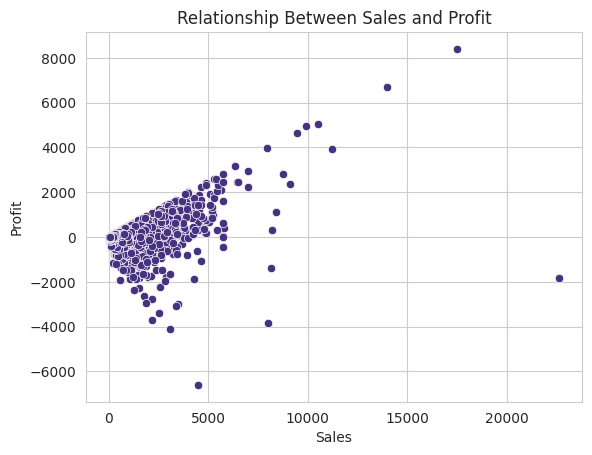

In [ ]:
sns.scatterplot(x = df['Sales'], y = df['Profit'])
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Relationship Between Sales and Profit')
plt.show()

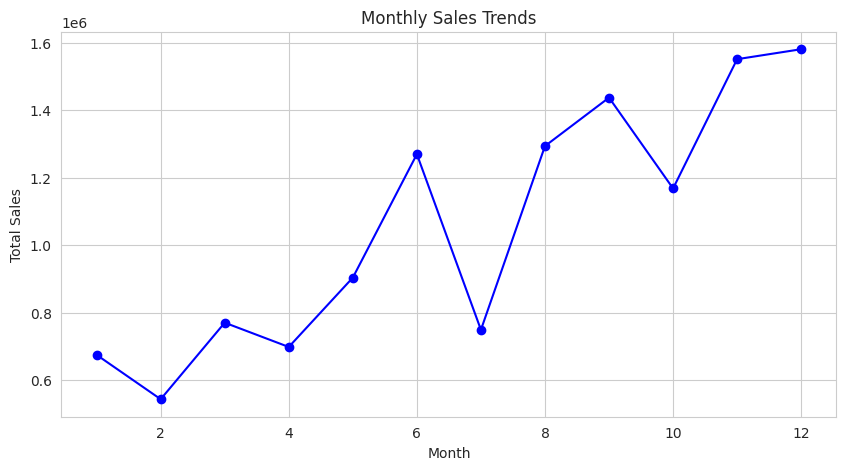

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot(marker='o', linestyle='-', color='blue')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trends')
plt.show()

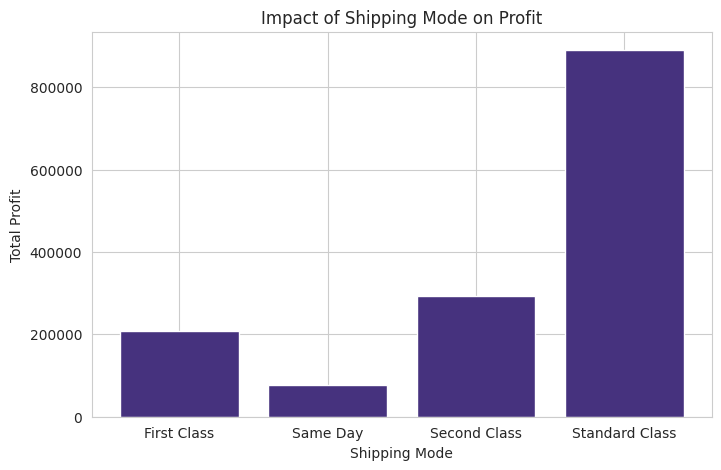

In [ ]:
shipping_profit = df.groupby('Ship Mode')['Profit'].sum()
plt.figure(figsize=(8, 5))
plt.bar(shipping_profit.index, shipping_profit.values)
plt.xlabel('Shipping Mode')
plt.ylabel('Total Profit')
plt.title('Impact of Shipping Mode on Profit')
plt.show()

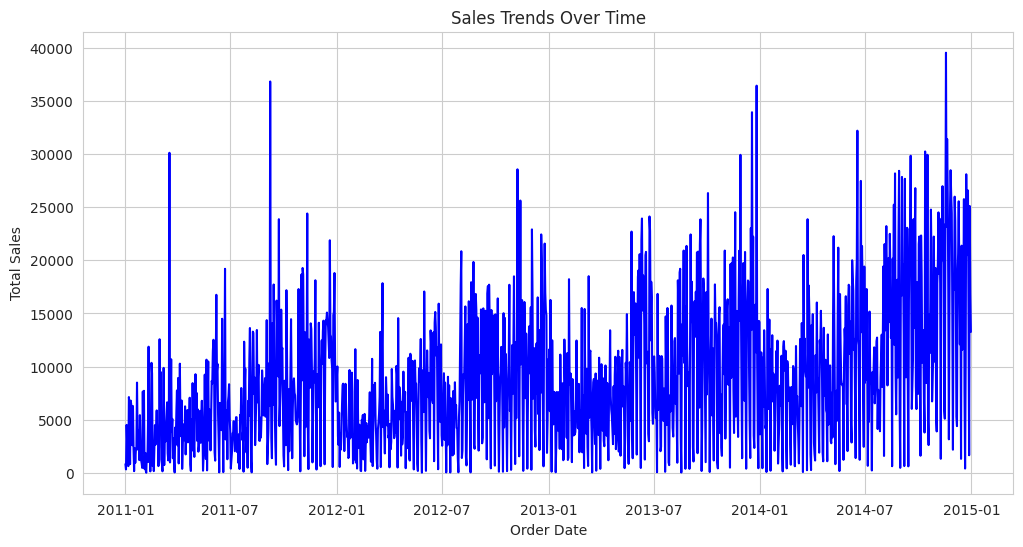

In [ ]:
# Group sales by order date
#Within each group (each date), we take the "Sales" column and sum it up
sales_trend = df.groupby("Order Date")["Sales"].sum().reset_index()

# Plot line chart
plt.figure(figsize=(12,6)) #Creates a new blank figure with 12 inches wide and 6 inches tall
plt.plot(sales_trend["Order Date"], sales_trend["Sales"], color="blue") #time series line plot of sales over dates.
plt.title("Sales Trends Over Time")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.show()

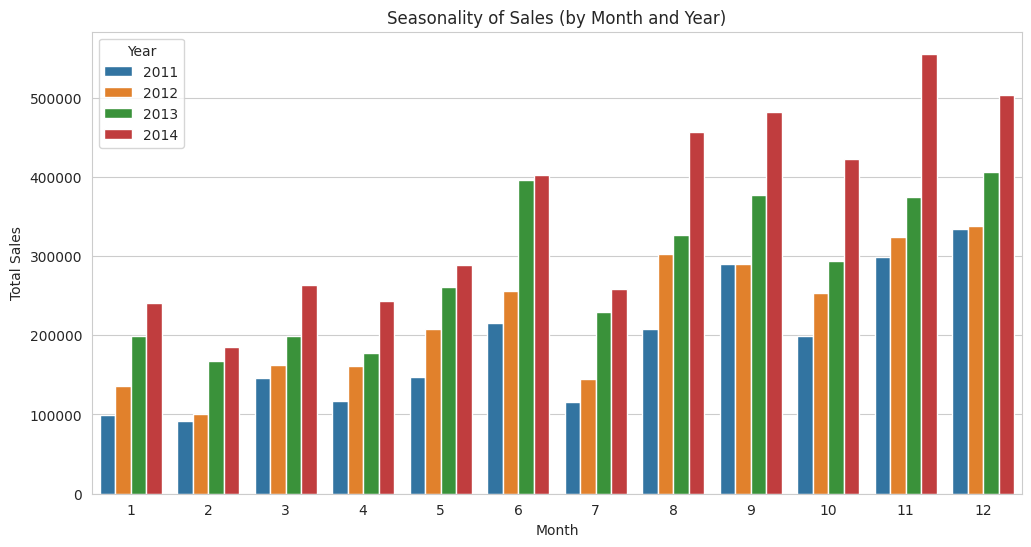

In [ ]:
# Extract Year and Month from Order Date
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

# Group sales & profit by Year-Month
monthly_sales = df.groupby(["Year","Month"])[["Sales","Profit"]].sum().reset_index()

# Plot monthly sales
plt.figure(figsize=(12,6))
sns.barplot(x="Month", y="Sales", hue="Year", data=monthly_sales, palette="tab10") #hue="Year" Different colors for different years ,,palette="tab10" Nice 10-color palette for different years
plt.title("Seasonality of Sales (by Month and Year)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend(title="Year") #legend to show which color corresponds to which year
plt.show()

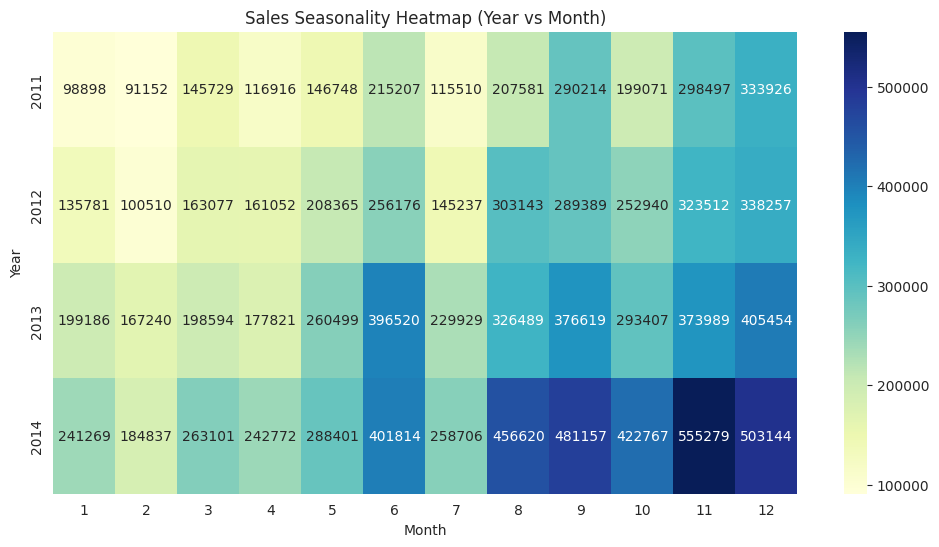

In [ ]:
#Turns the grouped data into a matrix
# Pivot the data: rows = Year, columns = Month, values = total Sales
sales_pivot = monthly_sales.pivot(index="Year", columns="Month", values="Sales")

# Plot heatmap
#Each cell represents Sales in that Year & Month.
#annot=True  Writes the sales numbers inside each cell.
plt.figure(figsize=(12,6))
sns.heatmap(sales_pivot, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Sales Seasonality Heatmap (Year vs Month)")
plt.xlabel("Month")#X-axis = months (1 - Jan, 12 - Dec).
plt.ylabel("Year")#Y-axis = years (2011, 2012, 2013…)
plt.show()
#Darker = higher sales
#Brighter=lower sales

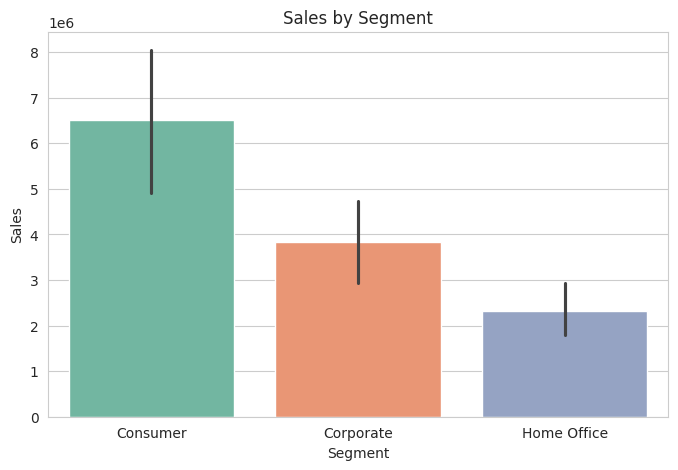

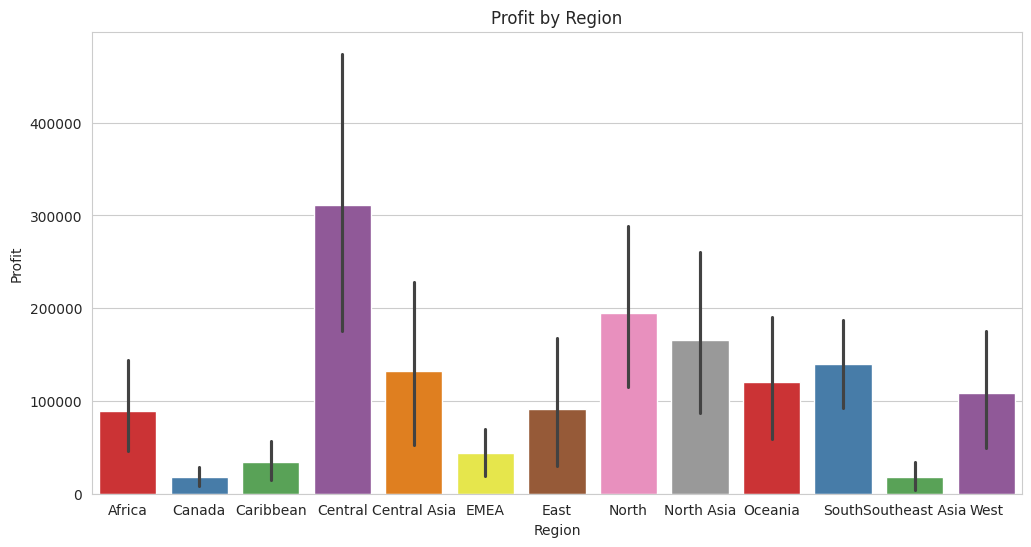

In [ ]:
# Group by Region, Market, Segment, and Order Priority
#reset_index():Makes sure the grouped categories become normal columns (not just index labels).
external = df.groupby(["Region","Market","Segment","Order Priority"])[["Sales","Profit","Quantity"]].sum().reset_index()

# Sales by Segment
plt.figure(figsize=(8,5))
#X-axis will show Segments (Consumer, Corporate, Home Office)
#data=external:Uses the grouped data we just made
#estimator=sum : Ensures sales values are summed (not averaged)
sns.barplot(x="Segment", y="Sales", data=external, estimator=sum, palette="Set2")
plt.title("Sales by Segment")
plt.show()

# Profit by Region
plt.figure(figsize=(12,6)) #Creates a new figure with size 8x5 inches.
sns.barplot(x="Region", y="Profit", data=external, estimator=sum, palette="Set1")
plt.title("Profit by Region")
plt.show()

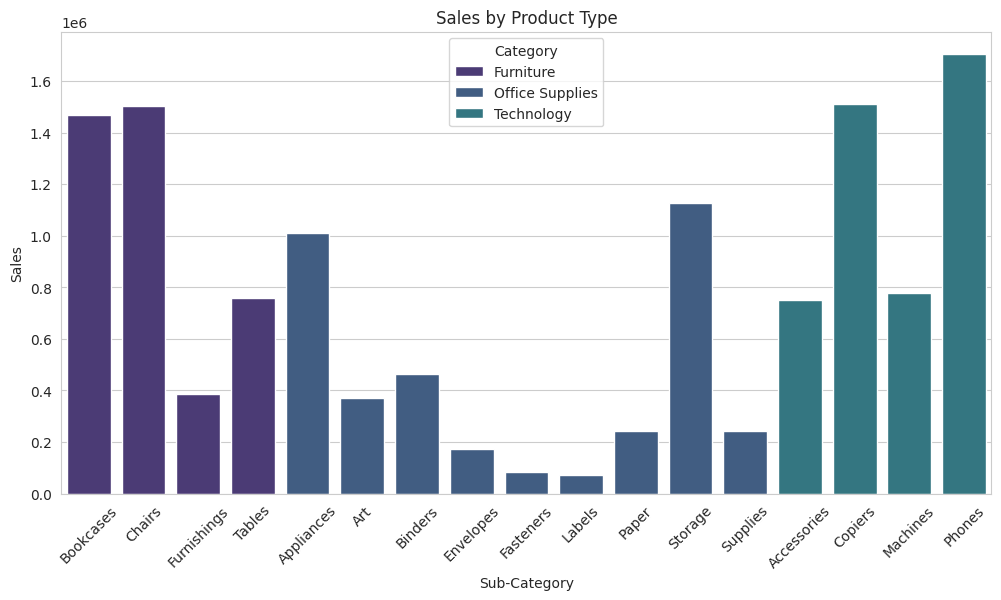

In [ ]:
# Group by Category and Sub-Category
product_sales = df.groupby(["Category","Sub-Category"])[["Sales","Quantity","Profit"]].sum().reset_index()

# Calculate Profit Margin = Profit / Sales
product_sales["Profit Margin"] = product_sales["Profit"] / product_sales["Sales"]

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x="Sub-Category", y="Sales", hue="Category", data=product_sales) #hue="Category" Different colors for each main Category (Furniture, Technology
plt.xticks(rotation=45) #Rotates x-axis labels by 45 degrees so the sub-category names don’t overlap
plt.title("Sales by Product Type")
plt.show()
#identify which products are profitable relative to sales volume.
#Each bar = Sales for a sub-category like Phones
#Colors distinguish which main category it belongs to.
#higher bars higher sales

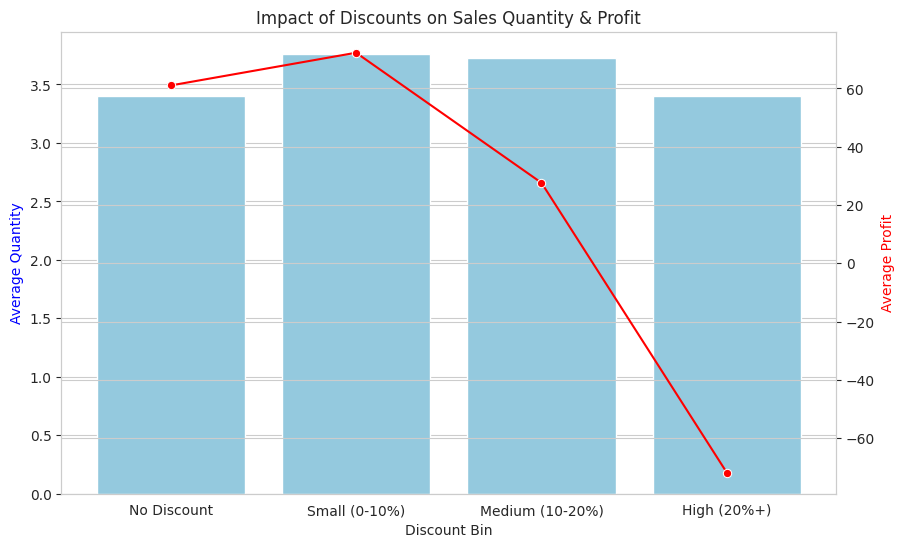

In [ ]:
# Create discount bins
bins = [0, 0.1, 0.2, 1.0]
labels = ["0-10% (Small)", "10-20% (Medium)", "20%+ (High)"]
df["Discount Bin"] = pd.cut(df["Discount"], bins=[-0.01, 0, 0.1, 0.2, 1], labels=["No Discount", "Small (0-10%)", "Medium (10-20%)", "High (20%+)"])

# Group by bins
discount_analysis = df.groupby("Discount Bin")[["Quantity","Profit"]].mean().reset_index()

# Plot
fig, ax1 = plt.subplots(figsize=(10,6))

sns.barplot(x="Discount Bin", y="Quantity", data=discount_analysis, color="skyblue", ax=ax1)
ax1.set_ylabel("Average Quantity", color="blue")

ax2 = ax1.twinx()
sns.lineplot(x="Discount Bin", y="Profit", data=discount_analysis, color="red", marker="o", ax=ax2)
ax2.set_ylabel("Average Profit", color="red")

plt.title("Impact of Discounts on Sales Quantity & Profit")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

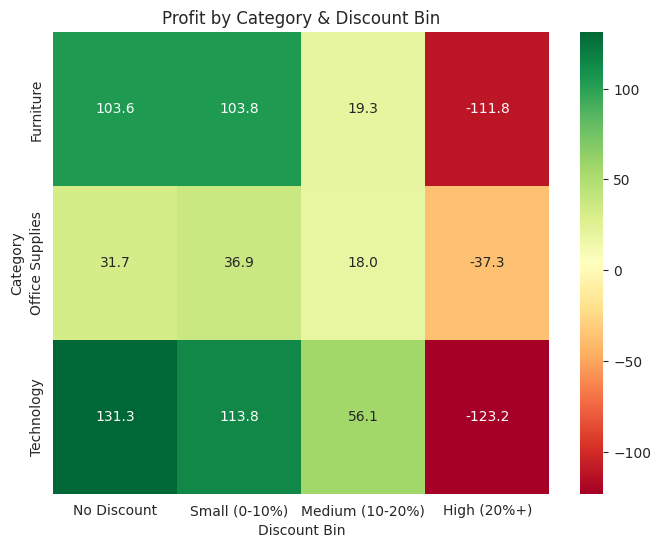

In [ ]:
# Group by Category and Discount Bin (with observed=True to silence the warning)
product_discount = df.groupby(["Category","Discount Bin"], observed=True)[["Quantity","Profit"]].mean().reset_index()

# Heatmap to see the relationship (using pivot_table instead of pivot)
#Reshapes the data into a matrix
pivot = product_discount.pivot_table(index="Category", columns="Discount Bin", values="Profit")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn")
#fmt=".1f" shows numbers with one decimal place
plt.title("Profit by Category & Discount Bin")
plt.show
#Each cell in the heat map shows the average profit for a category + discount level

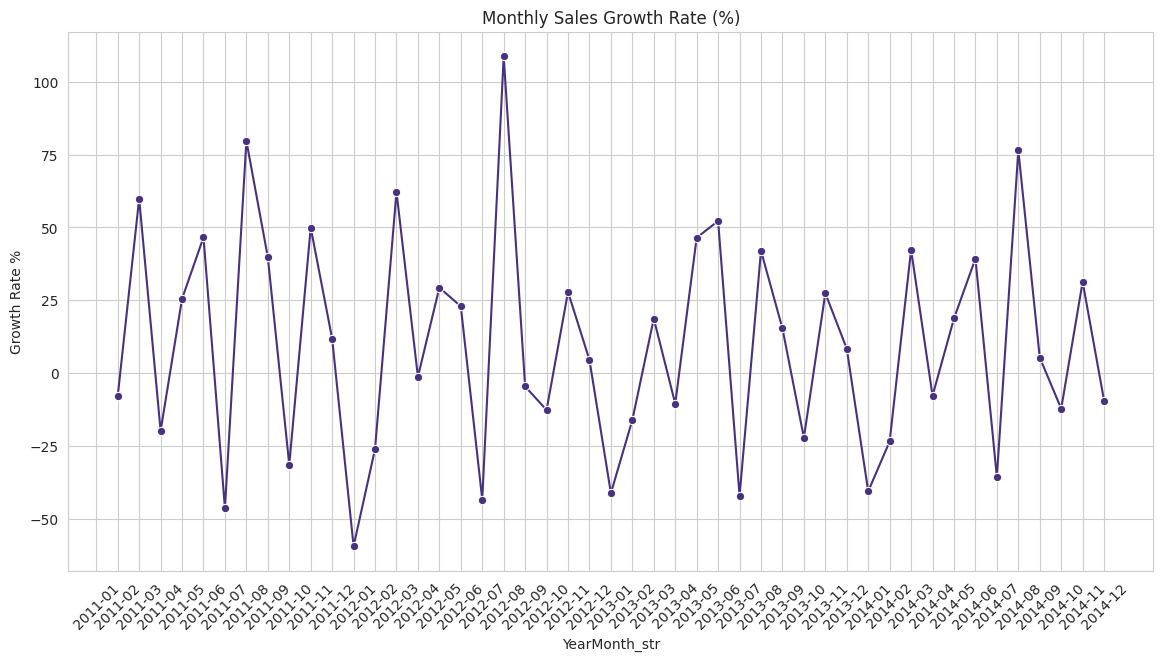

In [ ]:
# 1- (Growth Rate)

df["YearMonth"] = df["Order Date"].dt.to_period("M")#Creates a new column YearMonth from the Order Date
#dt.to_period("M") converts each order date into a year-month format
#lets us aggregate sales by month.
monthly_sales = df.groupby("YearMonth")["Sales"].sum().reset_index()
monthly_sales["Growth Rate"] = monthly_sales["Sales"].pct_change() * 100  #Calculates the percentage change in sales from one month to the next
#pct_change() computes growth

#transform YearMonth to string
monthly_sales["YearMonth_str"] = monthly_sales["YearMonth"].astype(str)

plt.figure(figsize=(14,7))
sns.lineplot(x="YearMonth_str", y="Growth Rate", data=monthly_sales, marker="o")
plt.title("Monthly Sales Growth Rate (%)")
plt.xticks(rotation=45)
plt.ylabel("Growth Rate %")
plt.show()

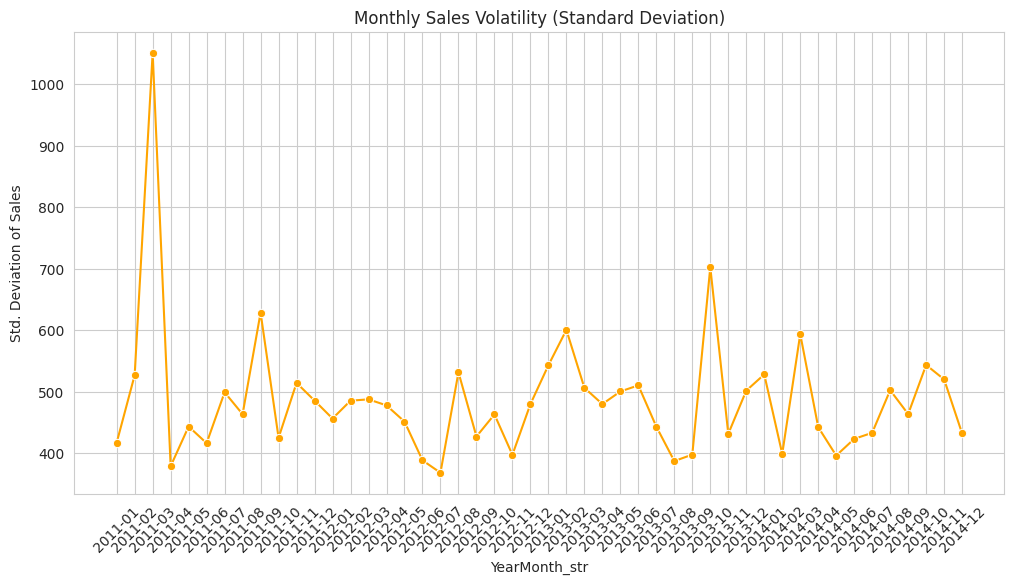

In [ ]:
# 2. (Volatility)
#Standard deviation is a measure of volatility higher values mean sales fluctuated a lot that month, lower values mean sales were more stable

volatility = df.groupby("YearMonth")["Sales"].std().reset_index()

# transform YearMonth to string
volatility["YearMonth_str"] = volatility["YearMonth"].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(x="YearMonth_str", y="Sales", data=volatility, marker="o", color="orange")
#x-axis = YearMonth_str (the months)
#y-axis = Sales (but here it represents standard deviation
plt.title("Monthly Sales Volatility (Standard Deviation)")
plt.xticks(rotation=45)
plt.ylabel("Std. Deviation of Sales")
plt.show()

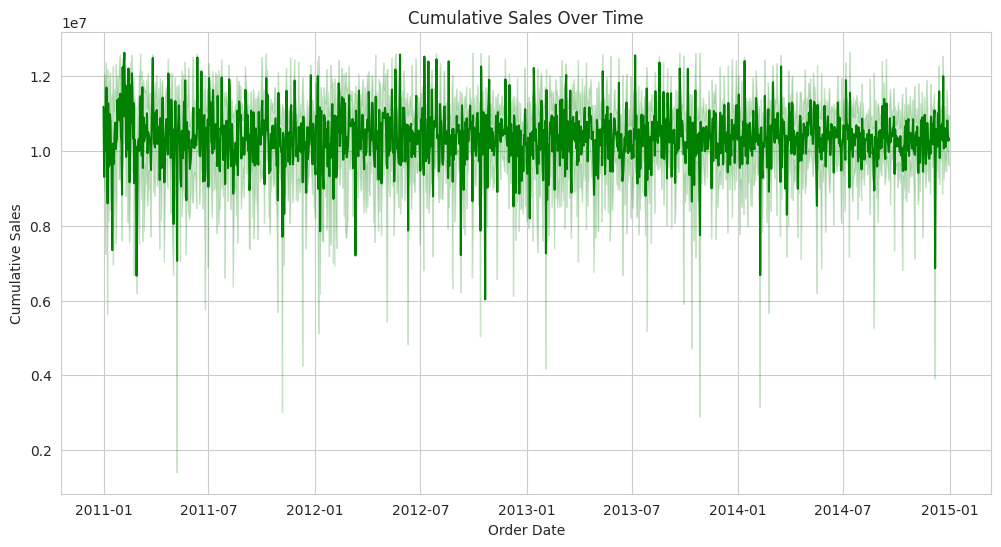

In [ ]:
# Creates a new column in the dataframe called Cumulative Sales
#it keeps adding each new order’s sales to the total so far
# ----------------------------
df["Cumulative Sales"] = df["Sales"].cumsum()

plt.figure(figsize=(12,6))
sns.lineplot(x="Order Date", y="Cumulative Sales", data=df, color="green")
plt.title("Cumulative Sales Over Time")
plt.ylabel("Cumulative Sales")
plt.show()
#shows how total sales accumulate over time.
#The slope of the line tells us how fast sales are growing
#A steep slope = strong sales in that period.......A flat slope = weak sales or no orders.

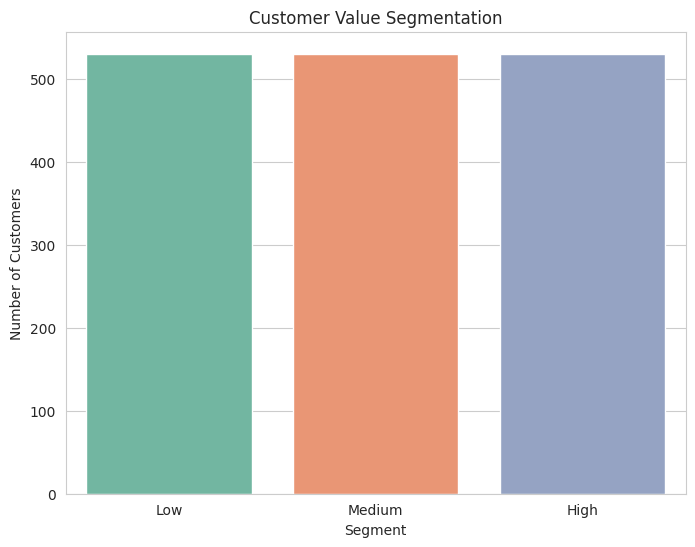

In [ ]:
#For each customer, calculates the total sales amount

customer_sales = df.groupby("Customer ID")["Sales"].sum().reset_index()

# pd.qcut=divides customers into 3 equal-sized group based on their total sales value.Labels them as "Low", "Medium", and "High"
customer_sales["Value Segment"] = pd.qcut(customer_sales["Sales"], q=3, labels=["Low","Medium","High"])

plt.figure(figsize=(8,6))
sns.countplot(x="Value Segment", data=customer_sales, palette="Set2")
plt.title("Customer Value Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

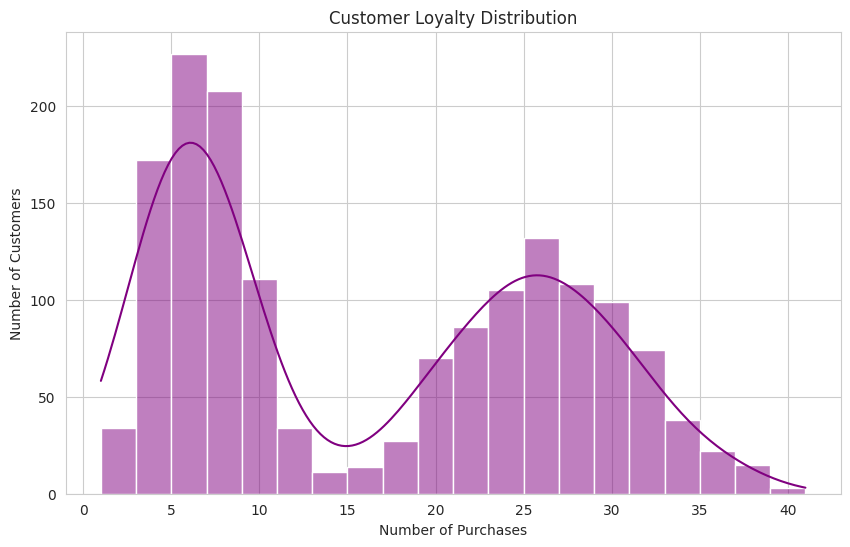

In [ ]:
#For each customer, counts the unique Order IDs
#example: Customer C001 placed 3 different orders
loyalty = df.groupby("Customer ID")["Order ID"].nunique().reset_index()
loyalty.columns = ["Customer ID","Purchase Count"]
#"Customer ID"  who the customer is
#"Purchase Count" how many times they bought from us.

plt.figure(figsize=(10,6))
sns.histplot(loyalty["Purchase Count"], bins=20, kde=True, color="purple")
#loyalty["Purchase Count"] = number of purchases each customer made.
#kde=True adds a smooth line to show the distribution curve.
plt.title("Customer Loyalty Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

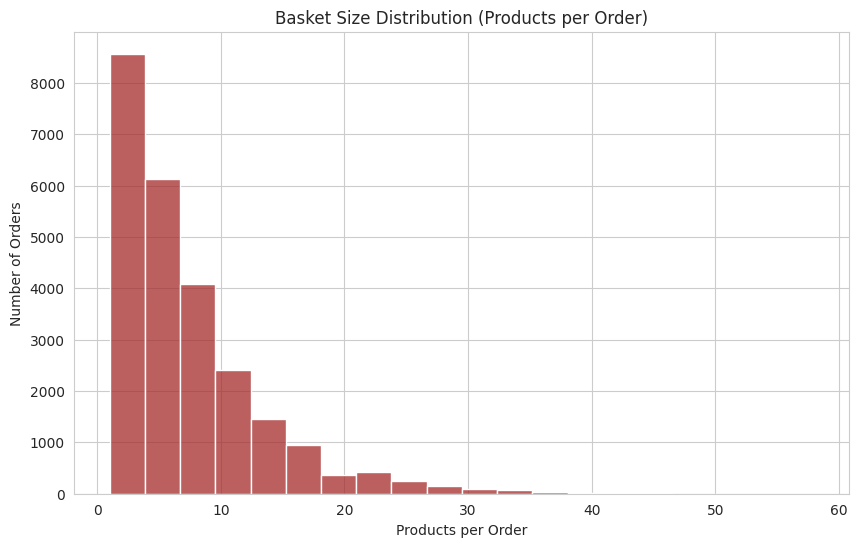

In [ ]:
#Groups the dataset by Order ID (each unique order)
#sums up the total number of items in that order
basket = df.groupby("Order ID")["Quantity"].sum().reset_index()

plt.figure(figsize=(10,6))
sns.histplot(basket["Quantity"], bins=20, color="brown")
#basket["Quantity"] the number of products per order
#bins=20 divides the data into 20 ranges (0–2, 3–5,...)
plt.title("Basket Size Distribution (Products per Order)")
plt.xlabel("Products per Order")#X-axis = how many products in an order
plt.ylabel("Number of Orders")#Y-axis = how many orders fall into that basket size.
plt.show()
#This chart shows how many products customers usually buy per order

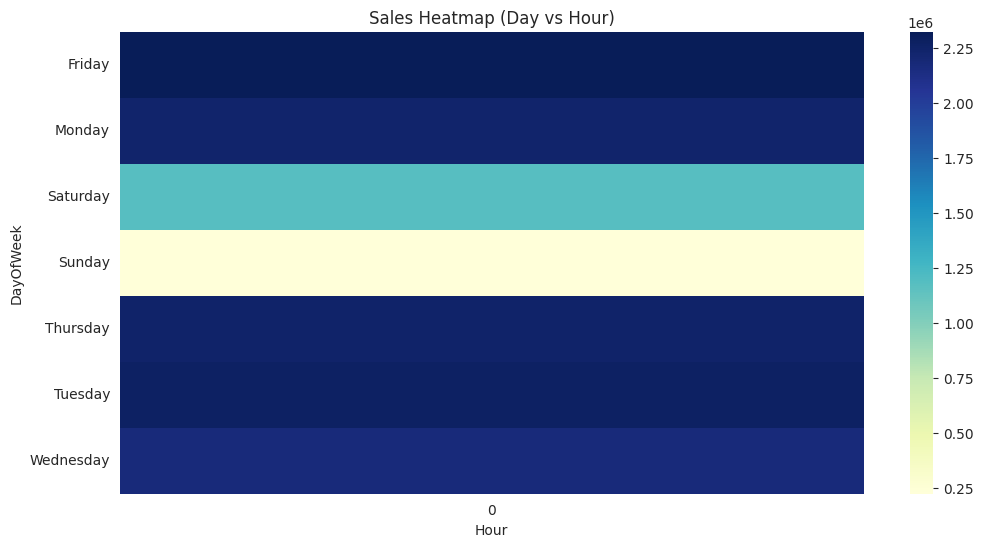

In [ ]:
# Convert Order Date to datetime
#errors="coerce" means if there are invalid values (like wrong date format), they’ll be replaced with NaT (Not a Time).
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

# If "Order Time" exists, use it otherwise extract from Order Date
if "Order Time" in df.columns:
    df["Hour"] = pd.to_datetime(df["Order Time"], format="%H:%M:%S").dt.hour
else:
    df["Hour"] = df["Order Date"].dt.hour
#Checks if there’s a separate Order Time column
#If yes converts it to datetime and extracts the hour
#If no extracts the hour directly from Order Date


#Creates a new column DayOfWeek by extracting the day name (Monday, Tuesday...) from the order date.
df["DayOfWeek"] = df["Order Date"].dt.day_name()

# Pivot Table for Heatmap
#rows = days of the week
#columns = hours of the day
#sales are summed up.
pivot = df.pivot_table(values="Sales", index="DayOfWeek", columns="Hour", aggfunc="sum")

# Plot
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Sales Heatmap (Day vs Hour)")
plt.show()

#Each cell is colored according to the sales amount
#Bigger sales = darker/stronger color.

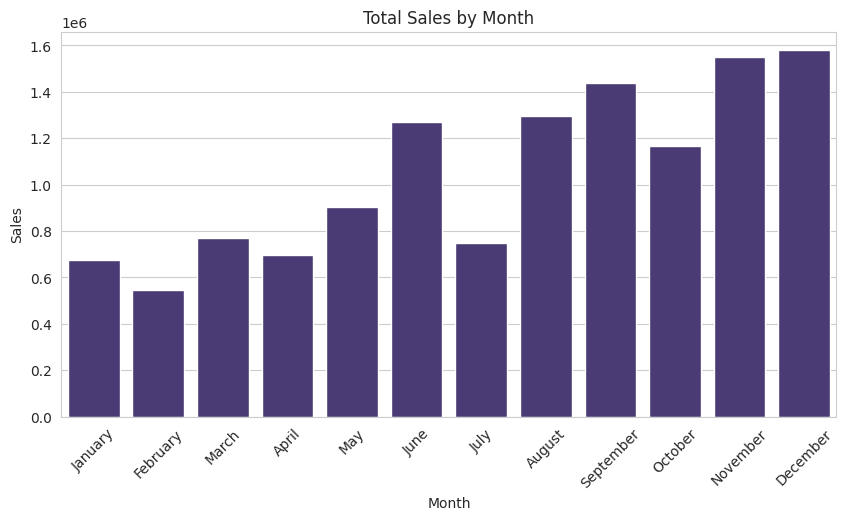

In [ ]:
# This chart shows total sales for each month, combining all years.
# It helps identify seasonal trends and which months have higher or lower sales.

# Convert Order Date to datetime if not already
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Year and Month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

# Total Sales by Month (across years)
monthly_sales = df.groupby('Month')['Sales'].sum().reindex([
    'January','February','March','April','May','June','July','August','September','October','November','December'
])

# Plot total sales per month as a bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title('Total Sales by Month')
plt.xticks(rotation=45)
plt.ylabel('Sales')
plt.show()

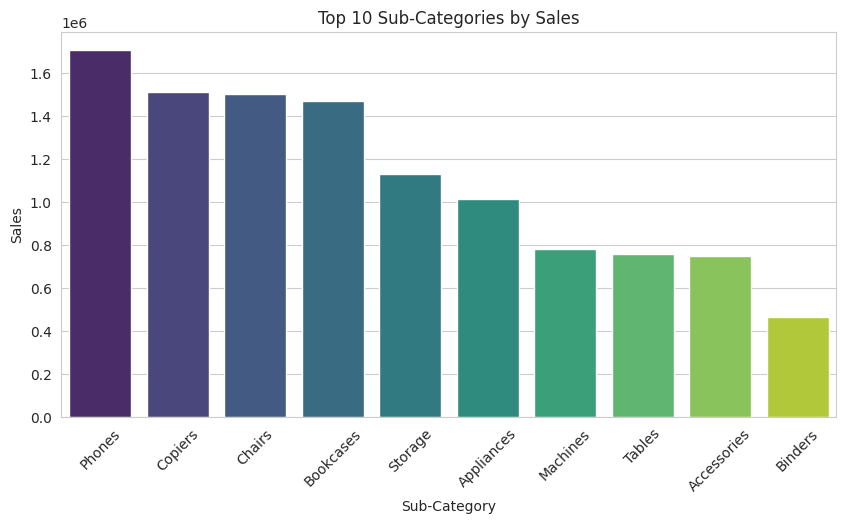

In [ ]:
# This bar chart shows the top 10 sub-categories with the highest total sales.
# It helps us quickly see which product sub-categories are generating the most revenue.
top_sub = df.groupby('Sub-Category')['Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x='Sub-Category', y='Sales', data=top_sub, palette='viridis')

# Add title and rotate x-axis labels for readability
plt.title('Top 10 Sub-Categories by Sales')
plt.xticks(rotation=45)
plt.show()

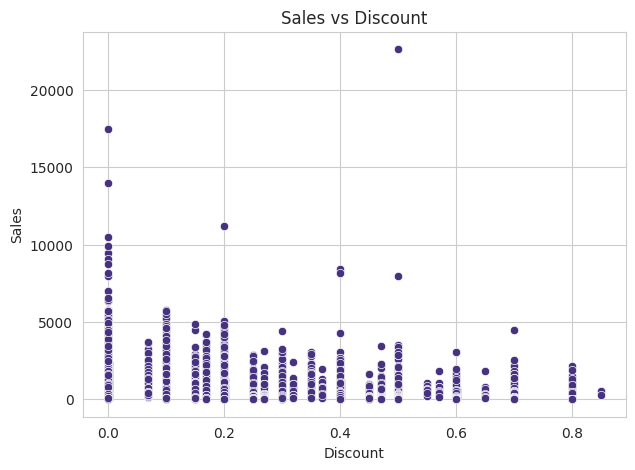

In [ ]:
# Scatter plot of Sales vs Discount
# This scatter plot shows actual sales for each transaction,
# allowing us to see individual data points, patterns, and outliers that averages hide.

plt.figure(figsize=(7,5))
sns.scatterplot(x='Discount', y='Sales', data=df)
plt.title('Sales vs Discount')
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.show()

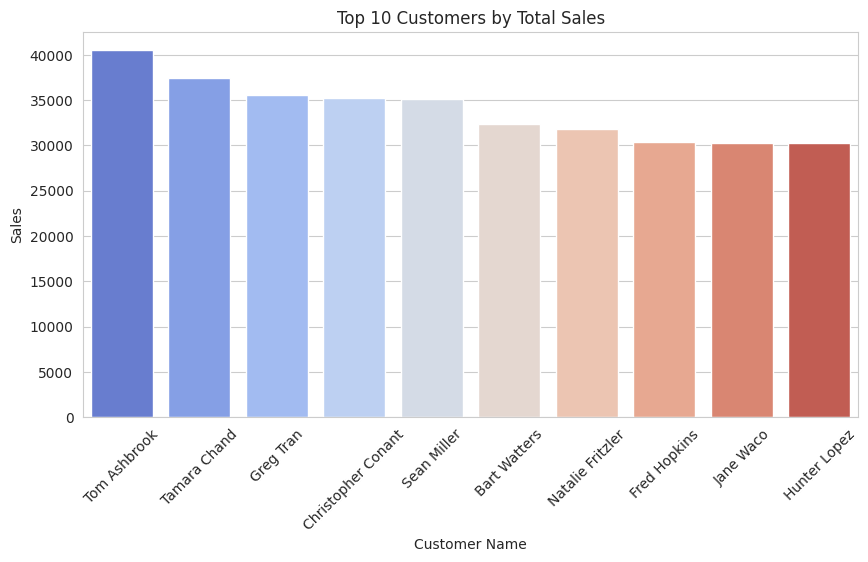

In [ ]:
# Find the top 10 customers with the highest total sales
# This bar chart helps identify which customers contribute the most revenue,
# giving insights into key clients for the business.
top_customers = df.groupby('Customer Name')['Sales'].sum().nlargest(10).reset_index()

# Plot a bar chart of top 10 customers
plt.figure(figsize=(10,5))
sns.barplot(
    x='Customer Name',
    y='Sales',
    data=top_customers,
    palette='coolwarm'  # Color palette for visual appeal
)

plt.title('Top 10 Customers by Total Sales')
plt.xticks(rotation=45)
plt.show()

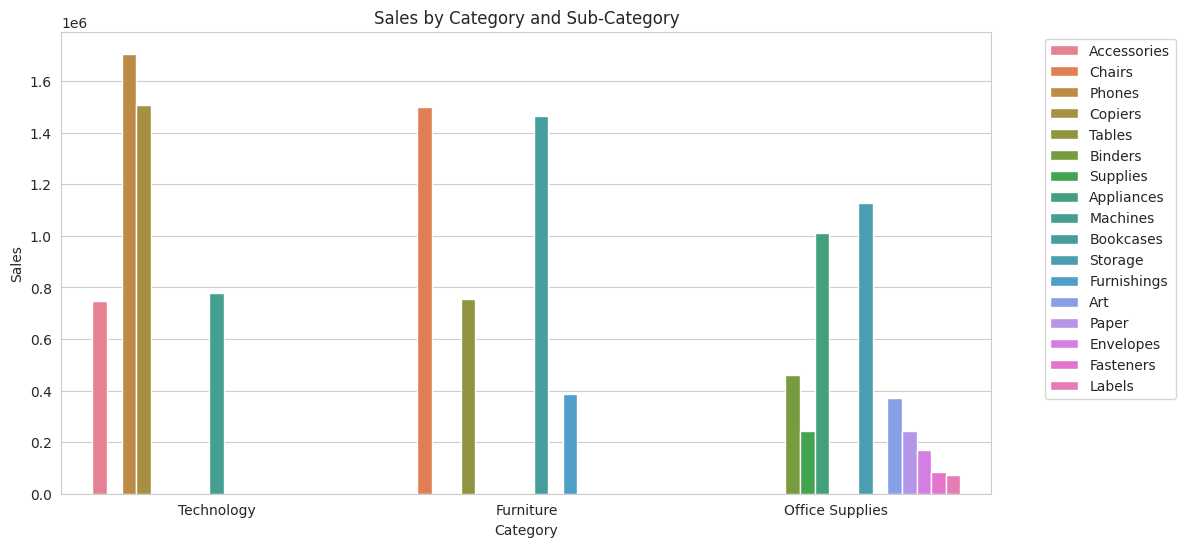

In [ ]:
# Stacked bar chart of total sales by Category and Sub-Category
# This chart shows how each Sub-Category contributes to the total sales of its Category.
# It helps identify which Sub-Categories are driving the sales within each main Category.
plt.figure(figsize=(12,6))
sns.barplot(
    x='Category',
    y='Sales',
    hue='Sub-Category',
    data=df,
    estimator='sum',  # Sum the sales for each Sub-Category
    ci=None            # Do not plot confidence interval
)
plt.title('Sales by Category and Sub-Category')
plt.ylabel('Sales')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside plot
plt.show()

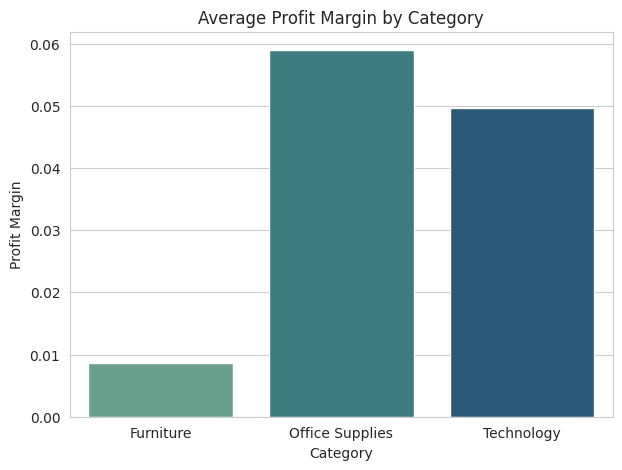

In [ ]:
# Calculate profit margin for each transaction
# Profit Margin shows how much profit the company makes from sales.
# - A higher value means the company keeps more profit from each sale,
# - A lower value means the profit from each sale is smaller.

# It's calculated as Profit divided by Sales.
df['Profit Margin'] = df['Profit'] / df['Sales']

# Compute average profit margin for each Category
avg_margin = df.groupby('Category')['Profit Margin'].mean().reset_index()

plt.figure(figsize=(7,5))

# Plot a bar chart showing average profit margin per Category
sns.barplot(
    x='Category',
    y='Profit Margin',
    data=avg_margin,
    palette='crest'
)
plt.title('Average Profit Margin by Category')
plt.ylabel('Profit Margin')
plt.show()

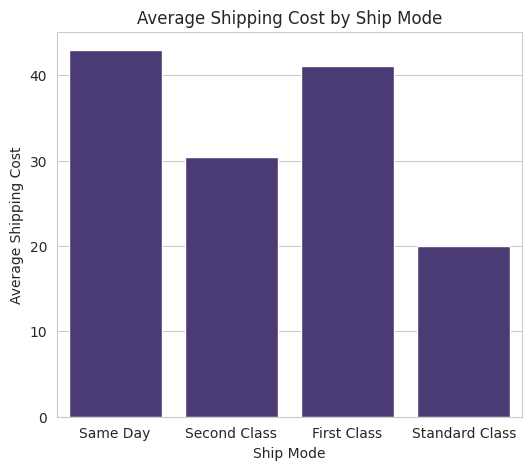

In [ ]:
# Plot the average shipping cost for each shipping mode
# This chart shows which shipping methods are more expensive on average.
# It helps identify potential areas to optimize shipping costs.

plt.figure(figsize=(6,5))
sns.barplot(
    x='Ship Mode',
    y='Shipping Cost',
    data=df,
    estimator='mean',  # Calculate average shipping cost per mode
    ci=None
)
plt.title('Average Shipping Cost by Ship Mode')
plt.ylabel('Average Shipping Cost')
plt.show()

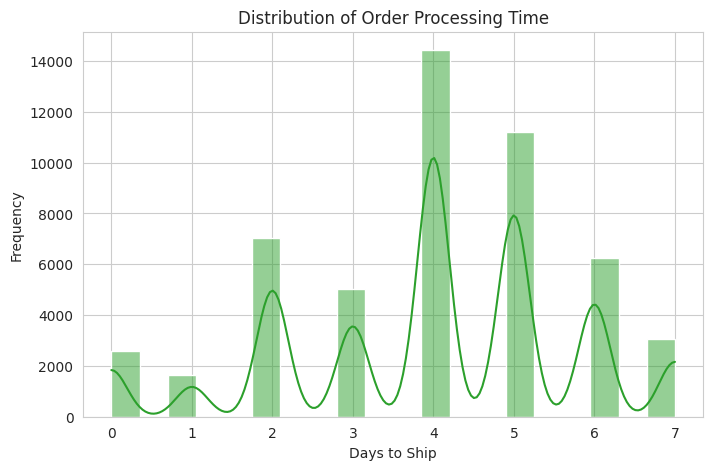

In [ ]:
# Processing Time shows how many days it takes to ship an order after it is placed.
# This histogram helps us see if most orders are shipped quickly or if some take longer than usual.

# Convert 'Ship Date' to datetime format (if not already)
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Calculate processing time for each order in days
# Processing Time = Ship Date - Order Date
df['Processing Time (Days)'] = (df['Ship Date'] - df['Order Date']).dt.days

plt.figure(figsize=(8,5))
sns.histplot(df['Processing Time (Days)'], bins=20, kde=True, color="#2CA02C")  # KDE line shows the overall distribution shape

plt.title('Distribution of Order Processing Time')
plt.xlabel('Days to Ship')
plt.ylabel('Frequency')
plt.show()

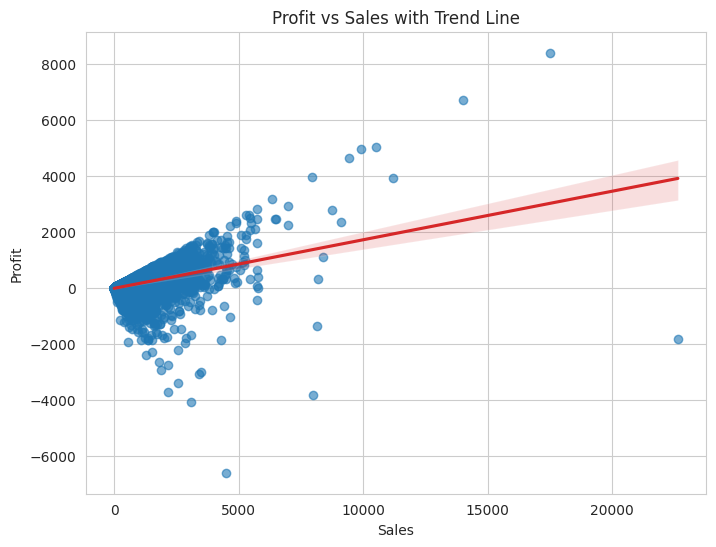

In [ ]:
# Scatter plot of Profit vs Sales with a trend line
# This plot helps us understand how profit generally changes as sales increase
# and also highlights outliers where profit might be unusually high or low.

plt.figure(figsize=(8,6))
sns.regplot(
    x='Sales',
    y='Profit',
    data=df,
    scatter_kws={'alpha':0.6, 'color':'#1F77B4'},
    line_kws={'color':'#D62728'}  # Thهس red line shows the overall trend between Sales and Profit.
)

plt.title('Profit vs Sales with Trend Line')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

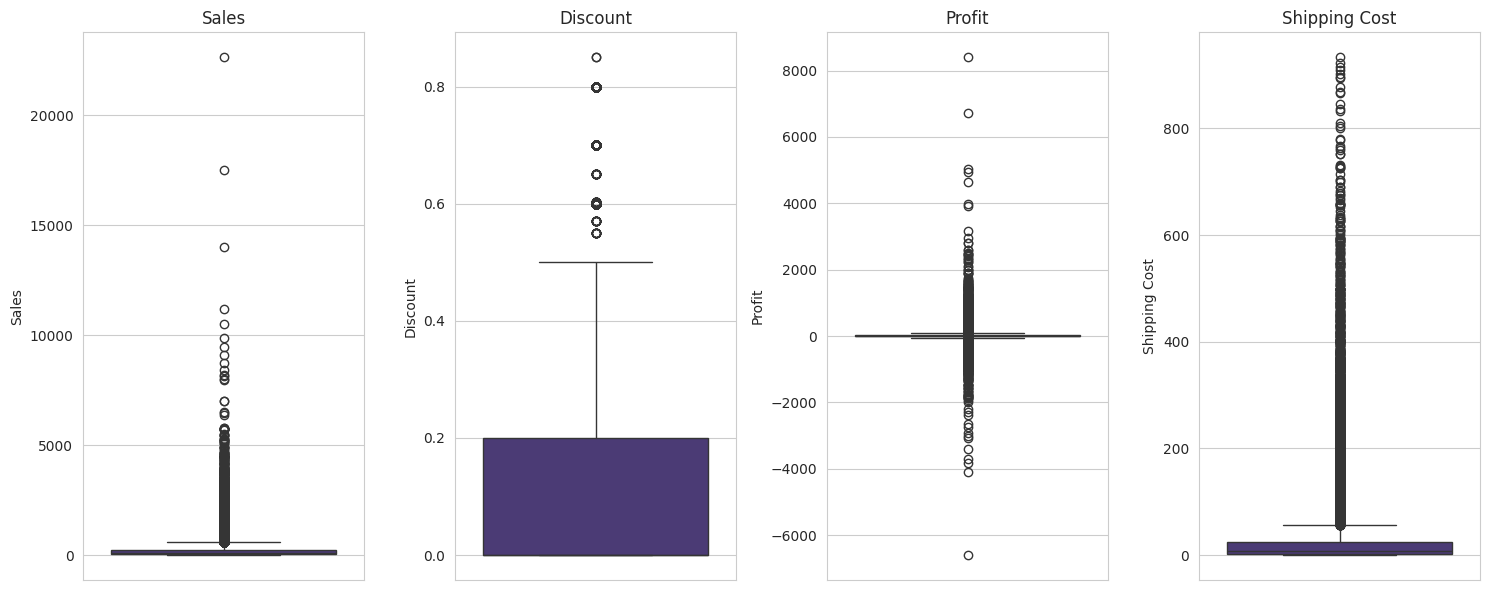

Outliers In Each Column: {'Sales': 5655, 'Discount': 4172, 'Profit': 9755, 'Shipping Cost': 5909}


In [ ]:
numeric_columns = ["Sales", "Discount", "Profit", "Shipping Cost"]

# Plot Outliers in each numerical column
plt.figure(figsize=(15, 6))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(1, len(numeric_columns), i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Calculate IQR
outliers = {}
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

print("Outliers In Each Column:", outliers)

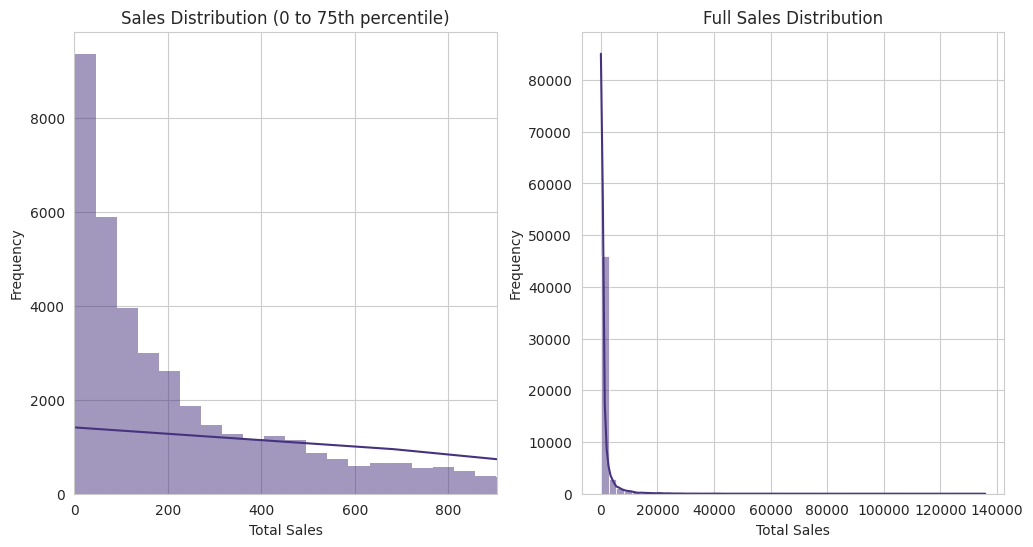

In [ ]:
# Plotting sales distribution focusing on 0–75th percentile using histogram + KDE
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Histogram showing the distribution of total sales (restricted to 75th percentile to reduce skewness)
sns.histplot(df['Total_sales'], kde=True, ax=axes[0])
axes[0].set_xlim(0, df['Total_sales'].quantile(0.75))
axes[0].set_title('Sales Distribution (0 to 75th percentile)')
axes[0].set_xlabel('Total Sales')
axes[0].set_ylabel('Frequency')

# Full distribution of total sales using more bins for higher granularity
sns.histplot(df['Total_sales'], kde=True, ax=axes[1], bins=50)
axes[1].set_title('Full Sales Distribution')
axes[1].set_xlabel('Total Sales')
axes[1].set_ylabel('Frequency')
plt.show()

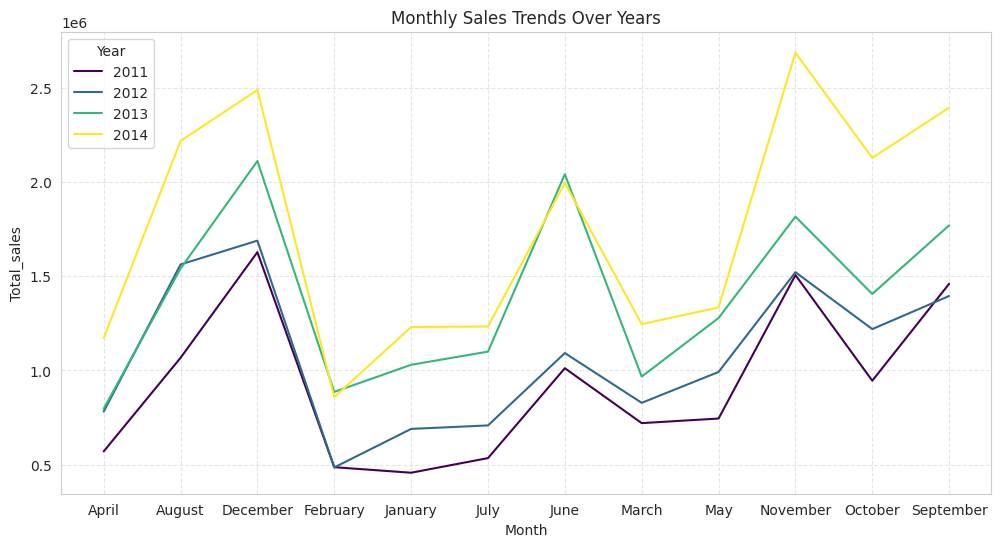

In [ ]:
# Monthly sales summed and visualized to show trends across years
monthly_sales = df.groupby(['Year', 'Month'])['Total_sales'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='Month', y='Total_sales', hue='Year', palette='viridis')
plt.title('Monthly Sales Trends Over Years')
plt.xlabel('Month')
plt.ylabel('Total_sales')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

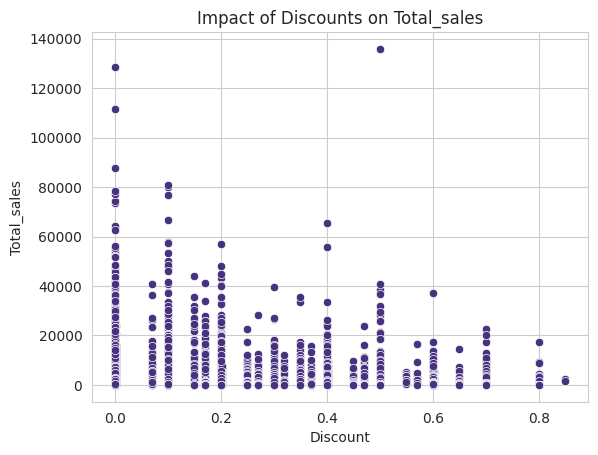

In [ ]:
# Scatter plot showing the relationship between discounts and total sales
sns.scatterplot(x=df['Discount'], y=df['Total_sales'])
plt.title("Impact of Discounts on Total_sales")
plt.show()

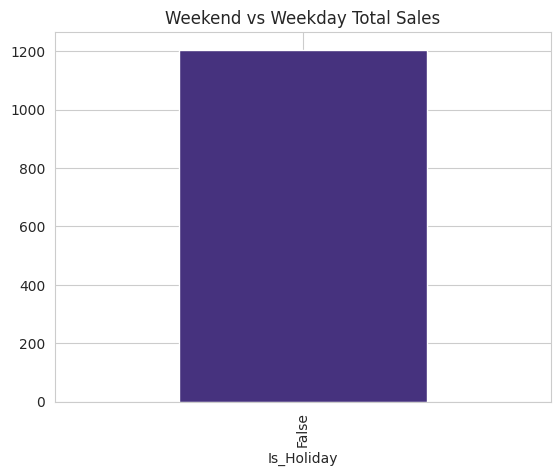

In [ ]:
# Create 'Is_Holiday' column: True if weekend, False otherwise
df["Is_Holiday"] = df["Day_of_Week"].isin(["Saturday", "Sunday"])

# plot average sales for weekends vs weekdays
df.groupby("Is_Holiday")["Total_sales"].mean().plot(
    kind="bar",
    title="Weekend vs Weekday Total Sales"
)
plt.show()

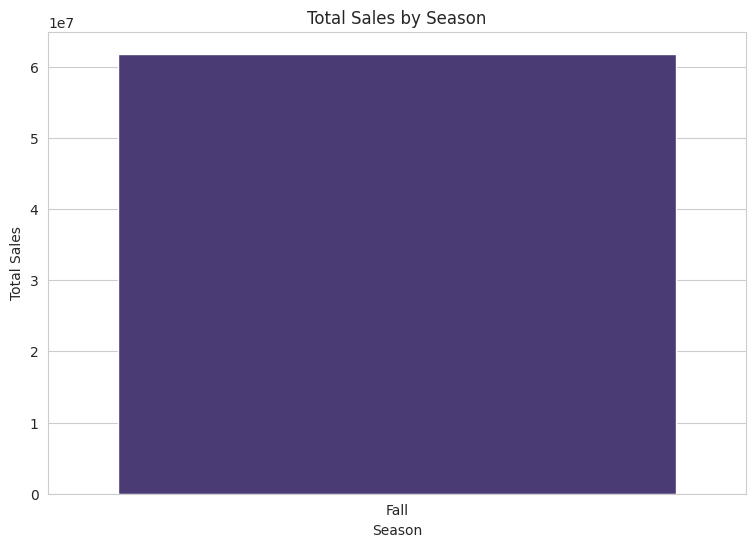

In [ ]:
# Create 'Season' column based on the month
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(get_season)
seasonal_sales = df.groupby('Season')['Total_sales'].sum().reset_index()

plt.figure(figsize=(9, 6))
sns.barplot(x='Season', y='Total_sales', data=seasonal_sales)
plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Sales')
plt.show()

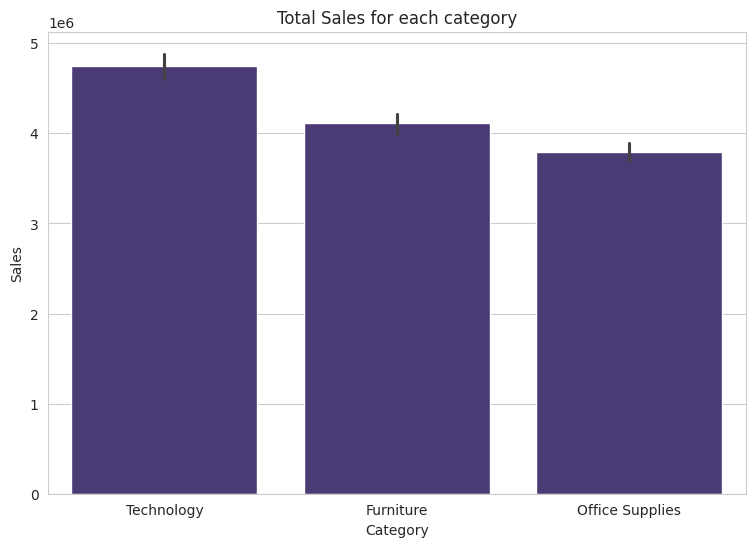

In [ ]:
# Bar plot showing total sales per product category
plt.figure(figsize=(9, 6))
sns.barplot(df, x='Category', y='Sales', estimator=sum)
plt.title('Total Sales for each category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

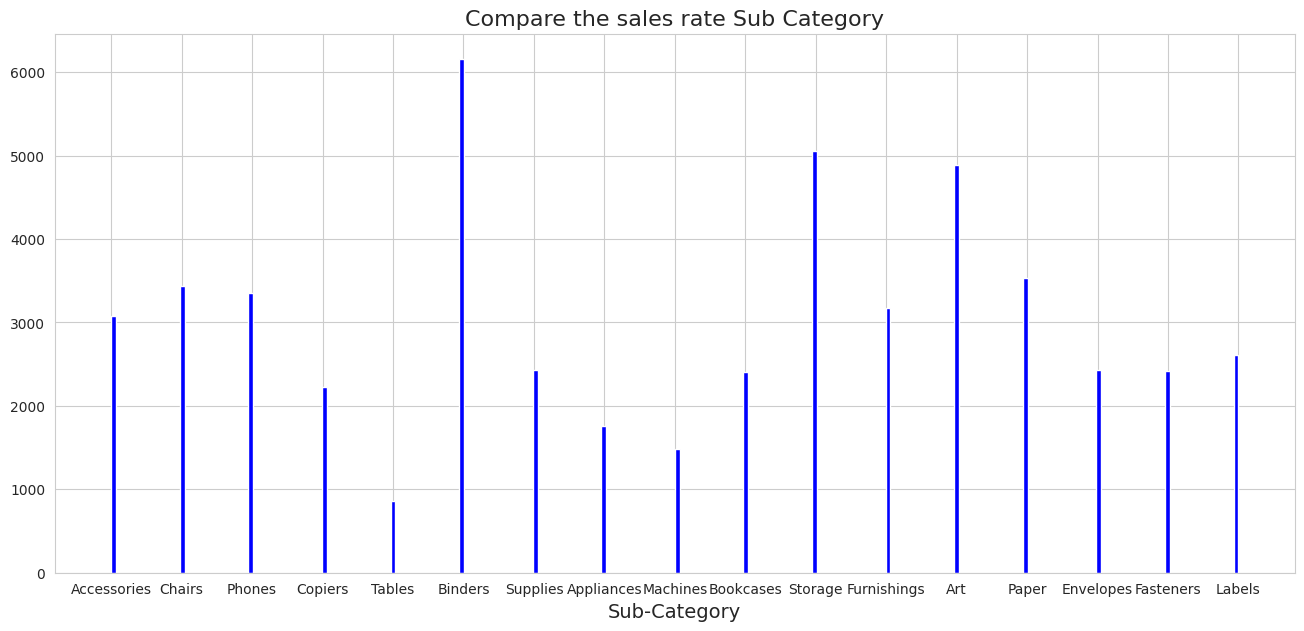

In [ ]:
# Histogram visualizing sales distribution across sub-categories
plt.figure(figsize=(16, 7))
plt.hist(df['Sub-Category'], color='blue', bins=230)
plt.title('Compare the sales rate Sub Category', fontsize='16')
plt.xlabel('Sub-Category', fontsize='14')
plt.show()

In [ ]:
# Grouped bar chart: Compare yearly sales across sub-categories using Plotly
fig = px.bar(
    df, x="Year", y="Sales", color="Sub-Category",
    barmode="group",
    title="Comparison of Sales by Year and Sub-Category",
    labels={"Total_sales": "Total Sales", "Year": "Year", "Sub-Category_Encoded": "Product Sub-Category"},
    height=600
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Sales",
    legend_title="Sub-Category",
    font=dict(size=12),
    template="plotly_white"
)

fig.show()

In [ ]:
cities = ['New York City', 'Los Angeles', 'Philadelphia', 'San Francisco', 'Santo Domingo']

EDA_MORE_5_CITIES = df[df['City'].isin(cities)]

In [ ]:

fig = px.bar(EDA_MORE_5_CITIES,
             x="Day_of_Week",
             y="Sales",
             color="Sub-Category",
             facet_col="City",
             barmode="group",
             title="Comparison of Sales by City, Sub-Category, and Day of Week",

             height=600)

fig.update_layout(
    yaxis_title="Total Sales",
    legend_title="Sub-Category",
    font=dict(size=12),
    template="plotly_white" ,
    width=4000
)
# This chart represents the top five cities by sales only

fig.show()

In [ ]:
# Choropleth map showing total sales distribution across countries
country_sales = df.groupby('Country')['Total_sales'].sum().reset_index()

fig = px.choropleth(country_sales,
                    locations="Country",
                    locationmode='country names',
                    color="Total_sales",
                    hover_name="Country",
                    color_continuous_scale=px.colors.sequential.Viridis,
                    title="Distribution of Total Sales Over Countries")

fig.show()

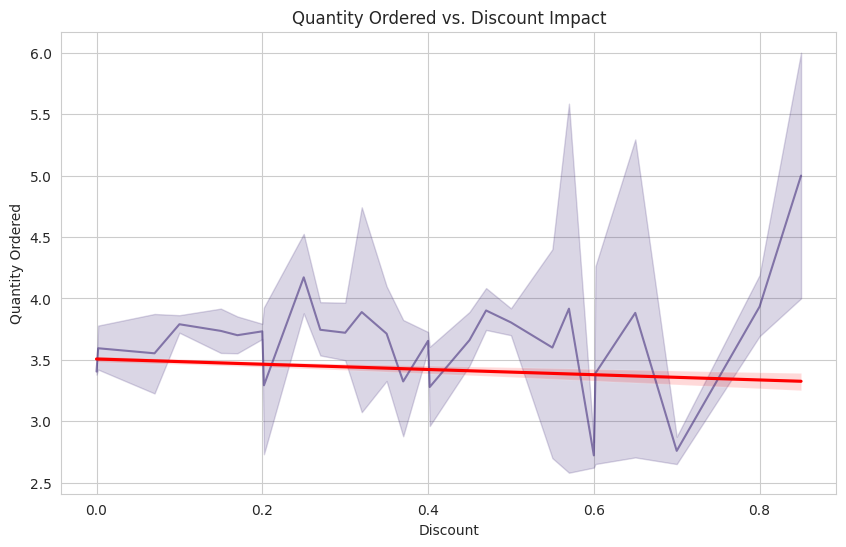

In [ ]:
# Line + regression plot showing how discount affects quantity ordered
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Discount", y="Quantity", alpha=0.6)
sns.regplot(data=df, x="Discount", y="Quantity", scatter=False, color="red")
plt.title("Quantity Ordered vs. Discount Impact")
plt.xlabel("Discount")
plt.ylabel("Quantity Ordered")
plt.grid(True)
plt.show()

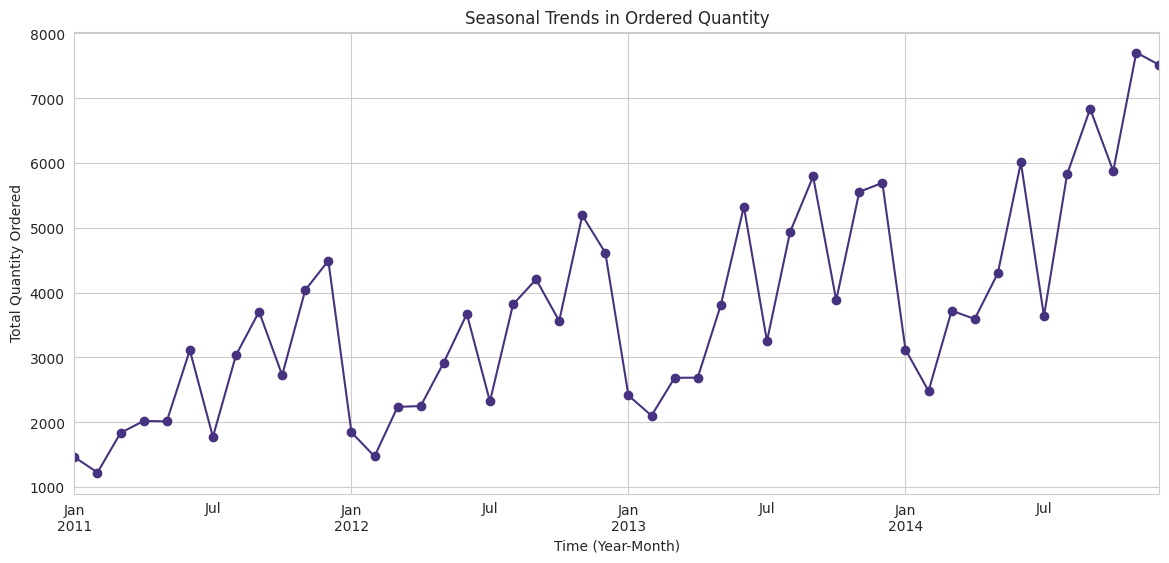

In [ ]:
# This section processes the order dates, aggregates the total ordered quantity on a monthly basis,
# and visualizes seasonal trends over time to identify patterns in customer purchasing behavior.
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year-Month"] = df["Order Date"].dt.to_period("M")
quantity_trend = df.groupby("Year-Month")["Quantity"].sum()

plt.figure(figsize=(14, 6))
quantity_trend.plot(marker="o", linestyle="-")
plt.title("Seasonal Trends in Ordered Quantity")
plt.xlabel("Time (Year-Month)")
plt.ylabel("Total Quantity Ordered")
plt.grid(True)
plt.show()

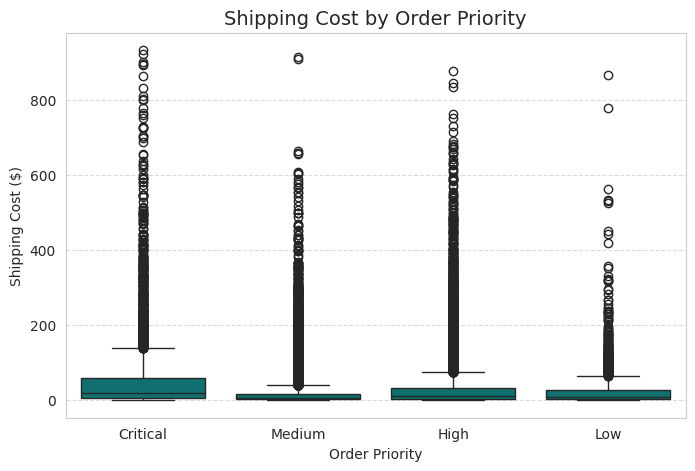

In [ ]:
# Boxplot showing distribution of shipping cost across order priority levels
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Order Priority", y="Shipping Cost",color="Teal")
plt.title("Shipping Cost by Order Priority", fontsize=14)
plt.xlabel("Order Priority")
plt.ylabel("Shipping Cost ($)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

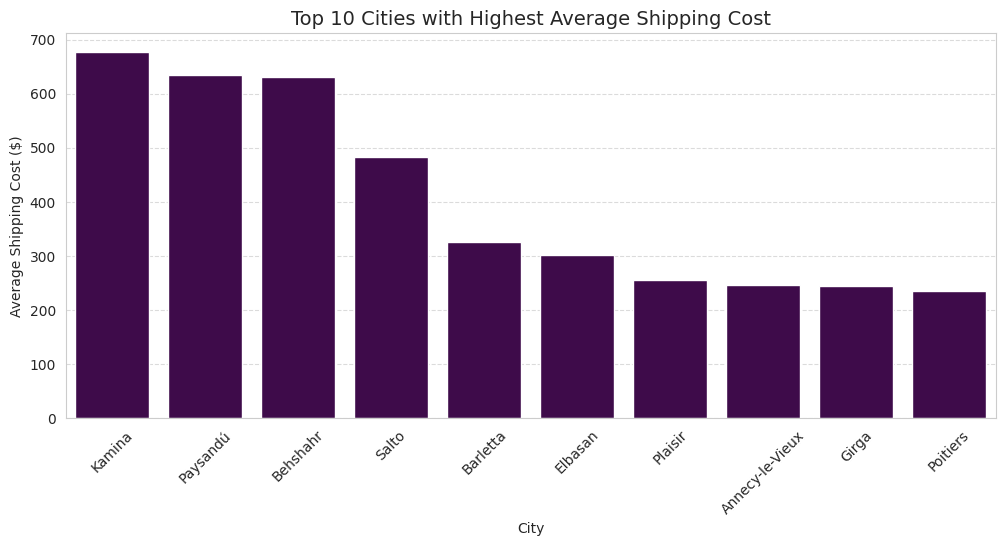

In [ ]:
# Bar chart of top 10 Markets with highest average shipping cost
plt.figure(figsize=(12, 5))
top_cities = df.groupby("City")["Shipping Cost"].mean().nlargest(10)
sns.barplot(x=top_cities.index, y=top_cities.values,color="#440154")
plt.title("Top 10 Cities with Highest Average Shipping Cost", fontsize=14)
plt.xlabel("City")
plt.ylabel("Average Shipping Cost ($)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

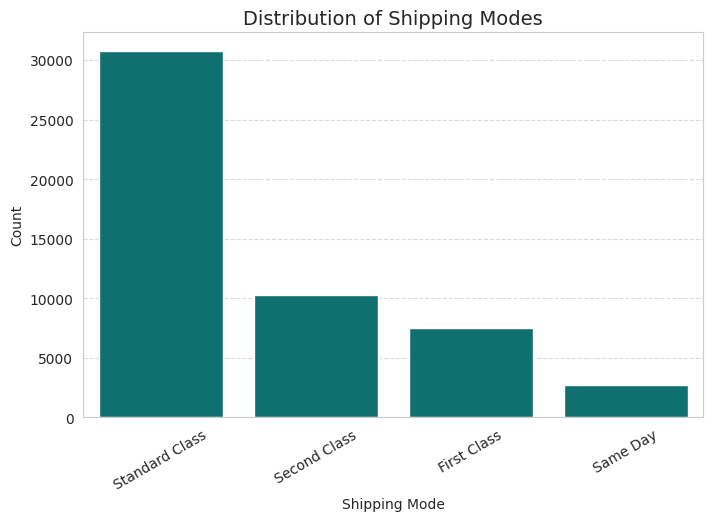

In [ ]:
# Count plot showing distribution of shipping modes used
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Ship Mode", order=df["Ship Mode"].value_counts().index,color = "Teal")
plt.title("Distribution of Shipping Modes", fontsize=14)
plt.xlabel("Shipping Mode")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

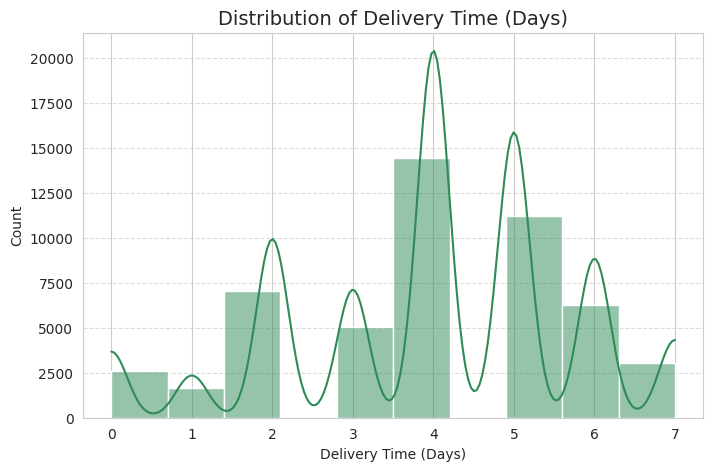

In [ ]:
df["Delivery Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

plt.figure(figsize=(8, 5))
sns.histplot(df["Delivery Time"], bins=10, kde=True, color="#2E8B57")
plt.title("Distribution of Delivery Time (Days)", fontsize=14)
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

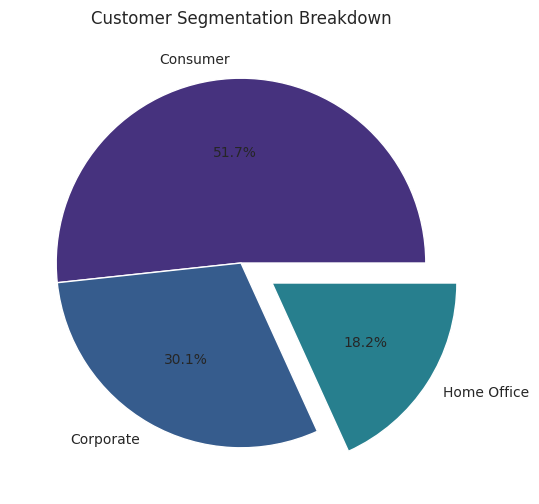

In [ ]:
# Pie chart showing percentage distribution of customer segments
customer_segments = df["Segment"].value_counts()
explode = (0, 0, 0.2)

plt.figure(figsize=(12, 6))
plt.pie(customer_segments, labels=customer_segments.index, autopct='%1.1f%%', explode=explode)
plt.title("Customer Segmentation Breakdown")
plt.show()

In [ ]:
# Grouping data into two discount groups and comparing their sales and profit per category
group_1=df[(df['Discount'] / df['Sales']) <= 0.01]
group_2=df[(df['Discount'] /df['Sales'] > 0.01) & (df['Discount'] / df['Sales'] <= 0.07)]
Dis_1=group_1.groupby('Category')[['Sales','Profit']].sum()
Dis_2=group_2.groupby('Category')[['Sales','Profit']].sum()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=Dis_1.index,
    y=Dis_1['Sales'],
    name='Sales (Group 1)',
    marker_color='skyblue'
))
fig.add_trace(go.Bar(
    x=Dis_1.index,
    y=Dis_1['Profit'],
    name='Profit (Group 1)',
    marker_color='lightblue'
))

fig.add_trace(go.Bar(
    x=Dis_2.index,
    y=Dis_2['Sales'],
    name='Sales (Group 2)',
    marker_color='lightgreen'
))
fig.add_trace(go.Bar(
    x=Dis_2.index,
    y=Dis_2['Profit'],
    name='Profit (Group 2)',
    marker_color='limegreen'
))



fig.update_layout(
    barmode='group',
    title='Sales and Profit by Category and Discount Group',
    xaxis_title='Category',
    yaxis_title='Amount',
    legend_title='Metric and Group',
    template='plotly_white'
)

fig.show()

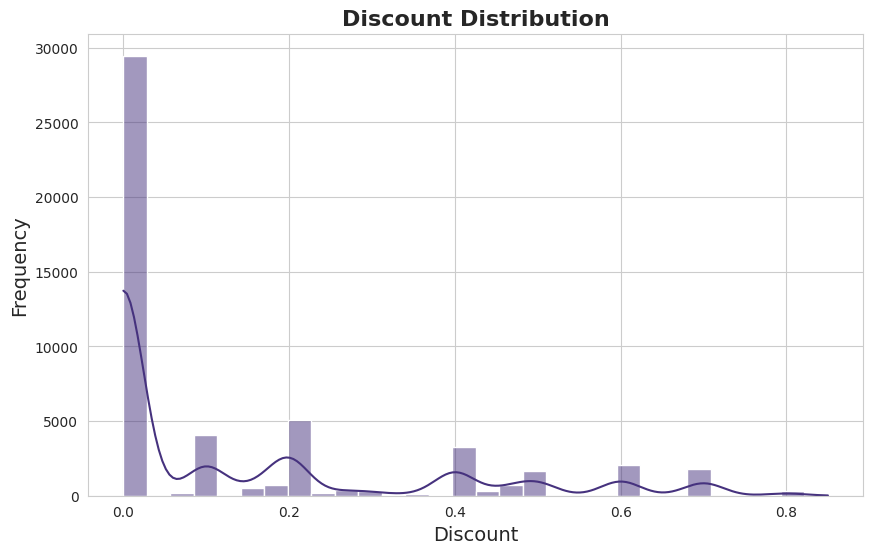

In [ ]:
# Histogram showing distribution of discount values
plt.figure(figsize=(10, 6))
sns.histplot(df['Discount'], bins=30, kde=True)
plt.title("Discount Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Discount", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.show()

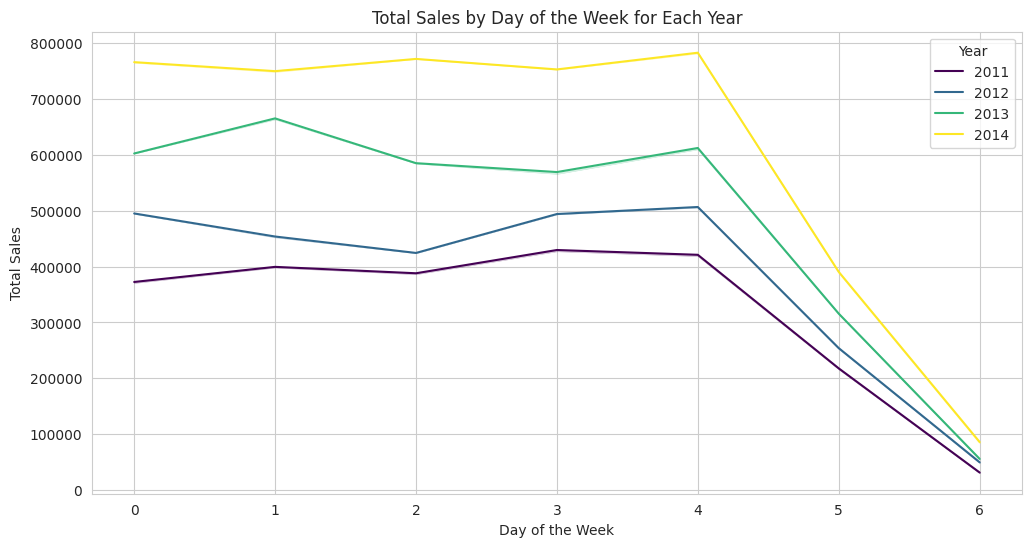

In [ ]:
# Line plot: total sales for each day of the week separated by year
plt.figure(figsize=(12, 6))
sns.lineplot(df, x='Day_of_Week', y='Sales', hue='Year', errorbar=('ci', False), estimator=sum, palette='viridis')
plt.title('Total Sales by Day of the Week for Each Year')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
# Boxplot showing distribution of shipping cost before outlier handling
fig = px.box(df, x='Shipping Cost', title='Boxplot of Shipping Cost')
fig.show()

In [ ]:
region_avg_order = df.groupby('Region')['Sales'].mean().round(2).sort_values(ascending=False)
region_avg_order = pd.DataFrame(region_avg_order)
region_avg_order

,Sales
Region,
Central Asia,367.59
North Asia,362.84
Oceania,315.51
Southeast Asia,282.65
North,260.85
Central,253.87
South,240.92
East,238.34
West,226.49


In [ ]:
df.drop(columns=['Row ID' ,'Order ID' ,'Customer ID','Postal Code','Product ID'] ,inplace=True)

In [ ]:
missing_values = pd.DataFrame(df.isna().sum())
missing_values


,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer Name,0
Segment,0
City,0
State,0
Country,0
Market,0
Region,0


In [ ]:
duplicates_values = df.duplicated().sum()
print(f"Number of Duplicates Values = {duplicates_values}")


Number of Duplicates Values = 0


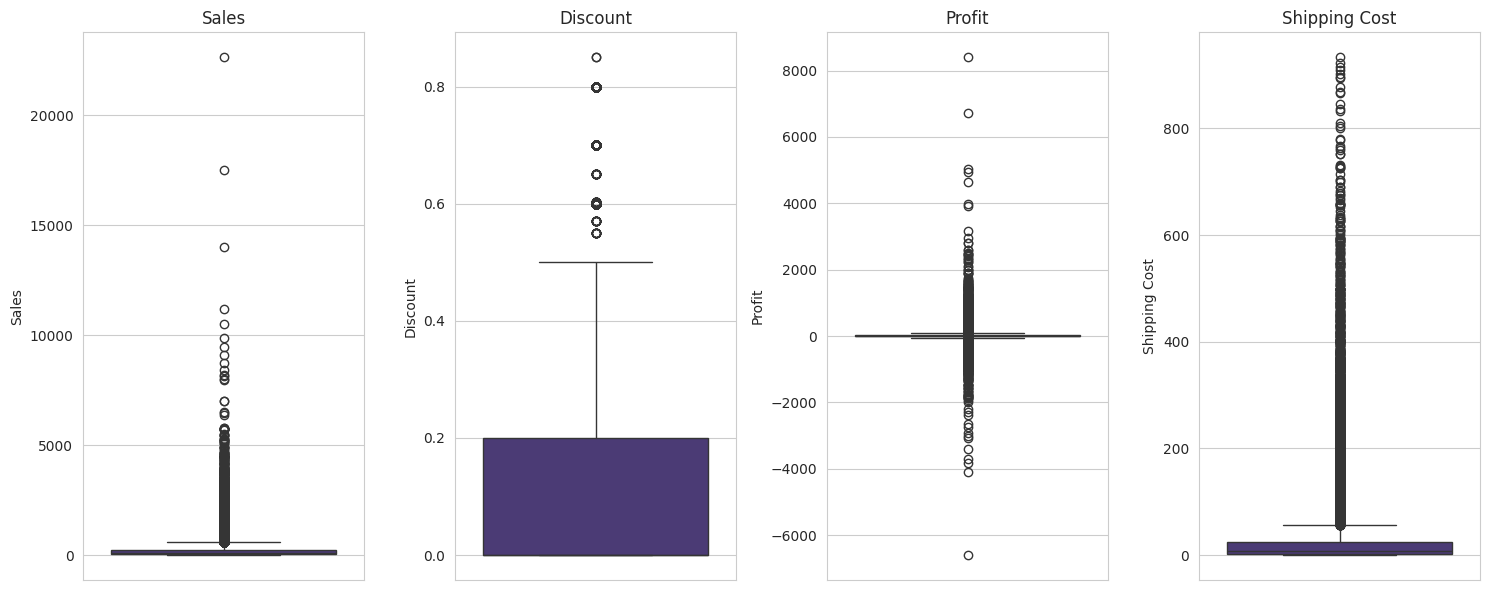

Outliers In Each Column: {'Sales': 5655, 'Discount': 4172, 'Profit': 9755, 'Shipping Cost': 5909}


In [ ]:
numeric_columns = ["Sales", "Discount", "Profit", "Shipping Cost"]

# Plot Outliers in each numerical column
plt.figure(figsize=(15, 6))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(1, len(numeric_columns), i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Calculate IQR
outliers = {}
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

print("Outliers In Each Column:", outliers)



In [ ]:
Basic_Statistics = df.describe(include=['number']).T
Basic_Statistics['skew'] = df.select_dtypes(include=['number']).apply(lambda x: x.skew())
Basic_Statistics['kurt'] = df.select_dtypes(include=['number']).apply(lambda x: x.kurt())
Basic_Statistics['median'] = df.select_dtypes(include=['number']).apply(lambda x: x.median())
Basic_Statistics['variance'] = df.select_dtypes(include=['number']).apply(lambda x: x.var())
Basic_Statistics['mode'] = df.select_dtypes(include=['number']).apply(lambda x: x.mode().values[0])
Basic_Statistics['range'] = Basic_Statistics['max'] - Basic_Statistics['min']

Basic_Statistics = Basic_Statistics[['count', 'mean', 'std', 'skew', 'kurt', 'min', '25%', '50%', '75%', 'max', 'range', 'mode', 'variance']]
Basic_Statistics


,count,mean,std,skew,kurt,min,25%,50%,75%,max,range,mode,variance
Sales,51290.0,2.464906e+02,4.875654e+02,8.138080,176.731200,0.444000,3.075863e+01,8.505300e+01,2.510532e+02,2.263848e+04,2.263804e+04,12.96,2.377200e+05
Quantity,51290.0,3.476545e+00,2.278766e+00,1.360368,2.275889,1.000000,2.000000e+00,3.000000e+00,5.000000e+00,1.400000e+01,1.300000e+01,2.00,5.192776e+00
Discount,51290.0,1.429075e-01,2.122799e-01,1.387775,0.716682,0.000000,0.000000e+00,0.000000e+00,2.000000e-01,8.500000e-01,8.500000e-01,0.00,4.506277e-02
Profit,51290.0,2.861098e+01,1.743410e+02,4.157189,291.411090,-6599.978000,0.000000e+00,9.240000e+00,3.681000e+01,8.399976e+03,1.499995e+04,0.00,3.039477e+04
Shipping Cost,51290.0,2.637592e+01,5.729680e+01,5.863226,50.020158,0.000000,2.610000e+00,7.790000e+00,2.445000e+01,9.335700e+02,9.335700e+02,0.86,3.282924e+03
Quarter,51290.0,2.793235e+00,1.066015e+00,-0.334947,-1.160328,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,4.00,1.136389e+00
Year,51290.0,2.012777e+03,1.098931e+00,-0.344515,-1.222033,2011.000000,2.012000e+03,2.013000e+03,2.014000e+03,2.014000e+03,3.000000e+00,2014.00,1.207650e+00
Day_of_Week,51290.0,2.343264e+00,1.671486e+00,0.159972,-1.040707,0.000000,1.000000e+00,2.000000e+00,4.000000e+00,6.000000e+00,6.000000e+00,4.00,2.793864e+00
Is_Weekend,51290.0,1.085982e-01,3.111374e-01,2.516040,4.330626,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.00,9.680649e-02
Total_sales,51290.0,1.205328e+03,3.452080e+03,10.314127,199.886920,0.444000,6.693000e+01,2.457720e+02,9.048750e+02,1.358309e+05,1.358304e+05,25.92,1.191685e+07


In [ ]:
df.describe(include=['number'])

,Sales,Quantity,Discount,Profit,Shipping Cost,Quarter,Year,Day_of_Week,Is_Weekend,Total_sales,Cumulative Sales,Hour,Profit Margin,Processing Time (Days),Delivery Time
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,5.129000e+04,51290.0,51290.000000,51290.000000,51290.000000
mean,246.490581,3.476545,0.142908,28.610982,26.375915,2.793235,2012.777208,2.343264,0.108598,1205.327987,1.031628e+07,0.0,0.047430,3.969370,3.969370
std,487.565361,2.278766,0.212280,174.340972,57.296804,1.066015,1.098931,1.671486,0.311137,3452.079528,2.756659e+06,0.0,0.465667,1.729437,1.729437
min,0.444000,1.000000,0.000000,-6599.978000,0.000000,1.000000,2011.000000,0.000000,0.000000,0.444000,2.309650e+03,0.0,-4.733542,0.000000,0.000000
25%,30.758625,2.000000,0.000000,0.000000,2.610000,2.000000,2012.000000,1.000000,0.000000,66.930000,9.250206e+06,0.0,0.000000,3.000000,3.000000
50%,85.053000,3.000000,0.000000,9.240000,7.790000,3.000000,2013.000000,2.000000,0.000000,245.772000,1.147750e+07,0.0,0.169178,4.000000,4.000000
75%,251.053200,5.000000,0.200000,36.810000,24.450000,4.000000,2014.000000,4.000000,0.000000,904.875000,1.231712e+07,0.0,0.333139,5.000000,5.000000
max,22638.480000,14.000000,0.850000,8399.976000,933.570000,4.000000,2014.000000,6.000000,1.000000,135830.880000,1.264250e+07,0.0,0.500000,7.000000,7.000000


In [ ]:
df.describe(include=['object', 'category'])

,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Order Priority,Month,Season,Discount Bin,DayOfWeek
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,4,795,3,3636,1094,147,7,13,3,17,3788,4,12,1,4,7
top,Standard Class,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,Office Supplies,Binders,Staples,Medium,November,Fall,No Discount,Friday
freq,30775,108,26518,915,2001,9994,11002,11117,31273,6152,227,29433,6342,51290,29009,9348


In [ ]:
df.describe(include='all')

,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290,51290,51290.000000,51290,51290,5.129000e+04,51290.0,51290,51290.000000,51290.000000,51290,51290.000000
unique,NaN,NaN,4,795,3,3636,1094,147,7,13,3,17,3788,NaN,NaN,NaN,NaN,NaN,4,12,NaN,NaN,NaN,NaN,1,1,NaN,4,48,NaN,NaN,7,NaN,NaN,48,NaN
top,NaN,NaN,Standard Class,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,NaN,Medium,November,NaN,NaN,NaN,NaN,False,Fall,NaN,No Discount,2014-12,NaN,NaN,Friday,NaN,NaN,2014-12,NaN
freq,NaN,NaN,30775,108,26518,915,2001,9994,11002,11117,31273,6152,227,NaN,NaN,NaN,NaN,NaN,29433,6342,NaN,NaN,NaN,NaN,51290,51290,NaN,29009,2153,NaN,NaN,9348,NaN,NaN,2153,NaN
mean,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,246.490581,3.476545,0.142908,28.610982,26.375915,NaN,NaN,2.793235,2012.777208,2.343264,0.108598,NaN,NaN,1205.327987,NaN,NaN,1.031628e+07,0.0,NaN,0.047430,3.969370,NaN,3.969370
min,2011-01-01 00:00:00,2011-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,0.000000,NaN,NaN,1.000000,2011.000000,0.000000,0.000000,NaN,NaN,0.444000,NaN,NaN,2.309650e+03,0.0,NaN,-4.733542,0.000000,NaN,0.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.758625,2.000000,0.000000,0.000000,2.610000,NaN,NaN,2.000000,2012.000000,1.000000,0.000000,NaN,NaN,66.930000,NaN,NaN,9.250206e+06,0.0,NaN,0.000000,3.000000,NaN,3.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.053000,3.000000,0.000000,9.240000,7.790000,NaN,NaN,3.000000,2013.000000,2.000000,0.000000,NaN,NaN,245.772000,NaN,NaN,1.147750e+07,0.0,NaN,0.169178,4.000000,NaN,4.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,251.053200,5.000000,0.200000,36.810000,24.450000,NaN,NaN,4.000000,2014.000000,4.000000,0.000000,NaN,NaN,904.875000,NaN,NaN,1.231712e+07,0.0,NaN,0.333139,5.000000,NaN,5.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.850000,8399.976000,933.570000,NaN,NaN,4.000000,2014.000000,6.000000,1.000000,NaN,NaN,135830.880000,NaN,NaN,1.264250e+07,0.0,NaN,0.500000,7.000000,NaN,7.000000


In [ ]:
fig = px.box(df, x='Shipping Cost', title='Boxplot of Shipping Cost')
fig.show()

In [ ]:
Q1 = df['Shipping Cost'].quantile(0.25)
Q3 = df['Shipping Cost'].quantile(0.75)
IQR = Q3 - Q1
lower_bound2 = Q1 - 1.5 * IQR
upper_bound2 = Q3 + 1.5 * IQR

outliers = df[(df['Shipping Cost'] < lower_bound2) | (df['Shipping Cost'] > upper_bound2)]
outliers



,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time
0,2012-07-31,2012-07-31,Same Day,Rick Hansen,Consumer,New York City,New York,United States,US,East,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.6500,7,0.00,762.1845,933.57,Critical,July,3,2012,1,0,False,Fall,16167.5500,No Discount,2012-07,2.309650e+03,0,Tuesday,0.330000,0,2012-07,0
1,2013-02-05,2013-02-07,Second Class,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.3950,9,0.10,-288.7650,923.63,Critical,February,1,2013,1,0,False,Fall,33384.5550,Small (0-10%),2013-02,6.019045e+03,0,Tuesday,-0.077847,2,2013-02,2
2,2013-10-17,2013-10-18,First Class,Craig Reiter,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.1710,9,0.10,919.9710,915.49,Medium,October,4,2013,3,0,False,Fall,46576.5390,Small (0-10%),2013-10,1.119422e+04,0,Thursday,0.177766,1,2013-10,1
3,2013-01-28,2013-01-30,First Class,Katherine Murray,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,"Motorola Smart Phone, Cordless",2892.5100,5,0.10,-96.5400,910.16,Medium,January,1,2013,0,0,False,Fall,14462.5500,Small (0-10%),2013-01,1.408673e+04,0,Monday,-0.033376,2,2013-01,2
4,2013-11-05,2013-11-06,Same Day,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.9600,8,0.00,311.5200,903.04,Critical,November,4,2013,1,0,False,Fall,22663.6800,No Discount,2013-11,1.691969e+04,0,Tuesday,0.109963,1,2013-11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5904,2011-10-19,2011-10-20,First Class,Justin Ellison,Corporate,Adelaide,South Australia,Australia,APAC,Oceania,Furniture,Chairs,"Harbour Creations Swivel Stool, Adjustable",493.0470,3,0.10,-21.9330,57.26,High,October,4,2011,2,0,False,Fall,1479.1410,Small (0-10%),2011-10,6.498621e+06,0,Wednesday,-0.044485,1,2011-10,1
5905,2014-12-30,2015-01-02,First Class,Harry Marie,Corporate,Basel,Basel-Stadt,Switzerland,EU,Central,Office Supplies,Art,"Sanford Canvas, Blue",151.5600,3,0.00,43.9200,57.25,Critical,December,4,2014,1,0,False,Fall,454.6800,No Discount,2014-12,6.498773e+06,0,Tuesday,0.289786,3,2014-12,3
5906,2013-11-17,2013-11-18,First Class,Tracy Collins,Home Office,Shanghai,Shanghai,China,APAC,North Asia,Furniture,Bookcases,"Bush Library with Doors, Mobile",366.8400,1,0.00,157.7400,57.23,High,November,4,2013,6,1,False,Fall,366.8400,No Discount,2013-11,6.499140e+06,0,Sunday,0.429997,1,2013-11,1
5907,2012-06-13,2012-06-17,Standard Class,Juliana Krohn,Consumer,Bangkok,Bangkok,Thailand,APAC,Southeast Asia,Technology,Copiers,"HP Fax Machine, Color",379.7388,2,0.37,-36.1812,57.21,High,June,2,2012,2,0,False,Fall,759.4776,High (20%+),2012-06,6.499519e+06,0,Wednesday,-0.095279,4,2012-06,4


In [ ]:
df['Shipping Cost'] = df['Shipping Cost'].apply(
    lambda x: df['Shipping Cost'].mean() if x < lower_bound2 or x > upper_bound2 else x
)

fig = px.box(df, x='Shipping Cost', title='Boxplot of Shipping Cost after Imputation')
fig.show()



In [ ]:
fig = px.box(df, x='Sales', title='Boxplot of Sales')
fig.show()


In [ ]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR2 = Q3 - Q1
lower_bound2 = Q1 - 1.5 * IQR2
upper_bound2 = Q3 + 1.5 * IQR2

outliers = df[(df['Sales'] < lower_bound2) | (df['Sales'] > upper_bound2)]
outliers


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time
0,2012-07-31,2012-07-31,Same Day,Rick Hansen,Consumer,New York City,New York,United States,US,East,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,26.375915,Critical,July,3,2012,1,0,False,Fall,16167.550,No Discount,2012-07,2.309650e+03,0,Tuesday,0.330000,0,2012-07,0
1,2013-02-05,2013-02-07,Second Class,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,26.375915,Critical,February,1,2013,1,0,False,Fall,33384.555,Small (0-10%),2013-02,6.019045e+03,0,Tuesday,-0.077847,2,2013-02,2
2,2013-10-17,2013-10-18,First Class,Craig Reiter,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,26.375915,Medium,October,4,2013,3,0,False,Fall,46576.539,Small (0-10%),2013-10,1.119422e+04,0,Thursday,0.177766,1,2013-10,1
3,2013-01-28,2013-01-30,First Class,Katherine Murray,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,26.375915,Medium,January,1,2013,0,0,False,Fall,14462.550,Small (0-10%),2013-01,1.408673e+04,0,Monday,-0.033376,2,2013-01,2
4,2013-11-05,2013-11-06,Same Day,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,26.375915,Critical,November,4,2013,1,0,False,Fall,22663.680,No Discount,2013-11,1.691969e+04,0,Tuesday,0.109963,1,2013-11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44220,2012-01-27,2012-02-02,Standard Class,Muhammed Yedwab,Corporate,Xichang,Sichuan,China,APAC,North Asia,Furniture,Chairs,"Office Star Swivel Stool, Set of Two",1585.710,9,0.0,0.0000,1.370000,Medium,January,1,2012,4,0,False,Fall,14271.390,No Discount,2012-01,1.251547e+07,0,Friday,0.000000,6,2012-01,6
45234,2014-09-15,2014-09-21,Standard Class,Giulietta Weimer,Consumer,Coulommiers,Ile-de-France,France,EU,Central,Furniture,Bookcases,"Ikea Floating Shelf Set, Pine",618.084,4,0.1,27.4440,1.190000,Low,September,3,2014,0,0,False,Fall,2472.336,Small (0-10%),2014-09,1.253943e+07,0,Monday,0.044402,6,2014-09,6
45351,2014-10-23,2014-10-26,First Class,Greg Tran,Consumer,Ulm,Baden-Württemberg,Germany,EU,Central,Technology,Machines,"Panasonic Inkjet, Wireless",936.270,3,0.0,65.5200,1.170000,Medium,October,4,2014,3,0,False,Fall,2808.810,No Discount,2014-10,1.254327e+07,0,Thursday,0.069980,3,2014-10,3
47131,2014-07-21,2014-07-26,Standard Class,Don Jones,Corporate,Maringá,Parana,Brazil,LATAM,South,Furniture,Chairs,"Novimex Executive Leather Armchair, Adjustable",607.360,2,0.0,133.6000,0.880000,Medium,July,3,2014,0,0,False,Fall,1214.720,No Discount,2014-07,1.258029e+07,0,Monday,0.219968,5,2014-07,5


In [ ]:

df['Sales'] = df['Sales'].apply(
    lambda x: df['Sales'].mean() if x <= lower_bound2 or x >= upper_bound2 else x
)

fig = px.box(df, x='Sales', title='Boxplot of Sales after Imputation')
fig.show()


In [ ]:
fig = px.box(df, x = df['Profit'])
fig.show()

In [ ]:
q1 = df['Profit'].quantile(0.25)
q3 = df['Profit'].quantile(0.75)
IQR = q3 - q1
lower_bound2 = q1 - 1.5 * IQR
upper_bound2 = q3 + 1.5 * IQR

outliers = df[(df['Profit'] < lower_bound2) | (df['Profit'] > upper_bound2)]
outliers

print(lower_bound2, upper_bound2)


-55.215 92.025


In [ ]:
df['Profit'] = df['Profit'].apply(
    lambda x: df['Profit'].median() if x < lower_bound2 or x > upper_bound2 else x
)

fig = px.box(df, x='Profit', title='Boxplot of Profit')
fig.show()


In [ ]:
fig = px.box(df, x = df['Discount'])
fig.show()

In [ ]:
q1 = df['Discount'].quantile(0.25)
q3 = df['Discount'].quantile(0.75)
IQR = q3 - q1
lower_bound2 = q1 - 1.5 * IQR
upper_bound2 = q3 + 1.5 * IQR

outliers = df[(df['Discount'] < lower_bound2) | (df['Discount'] > upper_bound2)]
outliers


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time
171,2013-11-26,2013-12-03,Standard Class,Cindy Stewart,Consumer,Lancaster,Ohio,United States,US,East,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,246.490581,5,0.70,9.240,26.375915,Low,November,4,2013,1,0,False,Fall,22499.925,High (20%+),2013-11,5.427196e+05,0,Tuesday,-1.466667,7,2013-11,7
245,2014-01-28,2014-01-30,Second Class,Julie Creighton,Corporate,Vilnius,Vilnius,Lithuania,EMEA,EMEA,Furniture,Tables,"Barricks Conference Table, Rectangular",246.490581,8,0.70,9.240,26.375915,High,January,1,2014,1,0,False,Fall,17369.280,High (20%+),2014-01,7.306407e+05,0,Tuesday,-1.266733,2,2014-01,2
289,2012-05-23,2012-05-26,First Class,Sarah Foster,Consumer,Izmir,Izmir,Turkey,EMEA,EMEA,Technology,Phones,"Samsung Audio Dock, with Caller ID",246.490581,14,0.60,9.240,26.375915,High,May,2,2012,2,0,False,Fall,13079.472,High (20%+),2012-05,8.234643e+05,0,Wednesday,-1.425373,3,2012-05,3
393,2014-07-14,2014-07-18,Second Class,Michael Moore,Consumer,Le Mans,Pays de la Loire,France,EU,Central,Technology,Phones,"Cisco Smart Phone, Cordless",246.490581,8,0.65,9.240,26.375915,High,July,3,2014,0,0,False,Fall,14593.152,High (20%+),2014-07,1.064658e+06,0,Monday,-0.714338,4,2014-07,4
481,2013-07-29,2013-07-30,First Class,Olvera Toch,Consumer,Bethlehem,Pennsylvania,United States,US,East,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,246.490581,6,0.70,9.240,26.375915,High,July,3,2013,0,0,False,Fall,8218.584,High (20%+),2013-07,1.249856e+06,0,Monday,-0.666667,1,2013-07,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51276,2014-06-09,2014-06-13,Standard Class,Dorris liebe,Corporate,Pasadena,Texas,United States,US,Central,Office Supplies,Appliances,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624000,2,0.80,-4.466,0.020000,Medium,June,2,2014,0,0,False,Fall,3.248,High (20%+),2014-06,1.264208e+07,0,Monday,-2.750000,4,2014-06,4
51278,2011-09-08,2011-09-10,Second Class,Patrick O'Donnell,Consumer,Lagos,Lagos,Nigeria,Africa,Africa,Office Supplies,Art,"Stanley Highlighters, Water Color",5.364000,1,0.70,-6.456,0.020000,High,September,3,2011,3,0,False,Fall,5.364,High (20%+),2011-09,1.264211e+07,0,Thursday,-1.203579,2,2011-09,2
51279,2011-03-21,2011-03-26,Standard Class,Alejandro Savely,Corporate,Harare,Harare,Zimbabwe,Africa,Africa,Office Supplies,Art,"Sanford Highlighters, Easy-Erase",9.612000,2,0.70,-21.168,0.020000,Medium,March,1,2011,0,0,False,Fall,19.224,High (20%+),2011-03,1.264212e+07,0,Monday,-2.202247,5,2011-03,5
51280,2014-11-29,2014-11-30,First Class,Karen Ferguson,Home Office,Midyat,Mardin,Turkey,EMEA,EMEA,Office Supplies,Art,"Boston Pens, Blue",34.128000,6,0.60,-49.572,0.020000,Medium,November,4,2014,5,1,False,Fall,204.768,High (20%+),2014-11,1.264215e+07,0,Saturday,-1.452532,1,2014-11,1


In [ ]:
df['Discount'] = df['Discount'].apply(
    lambda x: df['Discount'].median() if x < lower_bound2 or x > upper_bound2 else x
)

fig = px.box(df, x='Discount', title='Boxplot of Discount')
fig.show()


In [ ]:
df = pd.DataFrame(df)

print("Real Data:")
df.head()


Real Data:


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time
0,2012-07-31,2012-07-31,Same Day,Rick Hansen,Consumer,New York City,New York,United States,US,East,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,246.490581,7,0.0,9.24,26.375915,Critical,July,3,2012,1,0,False,Fall,16167.550,No Discount,2012-07,2309.650,0,Tuesday,0.330000,0,2012-07,0
1,2013-02-05,2013-02-07,Second Class,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",246.490581,9,0.1,9.24,26.375915,Critical,February,1,2013,1,0,False,Fall,33384.555,Small (0-10%),2013-02,6019.045,0,Tuesday,-0.077847,2,2013-02,2
2,2013-10-17,2013-10-18,First Class,Craig Reiter,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,"Nokia Smart Phone, with Caller ID",246.490581,9,0.1,9.24,26.375915,Medium,October,4,2013,3,0,False,Fall,46576.539,Small (0-10%),2013-10,11194.216,0,Thursday,0.177766,1,2013-10,1
3,2013-01-28,2013-01-30,First Class,Katherine Murray,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,"Motorola Smart Phone, Cordless",246.490581,5,0.1,9.24,26.375915,Medium,January,1,2013,0,0,False,Fall,14462.550,Small (0-10%),2013-01,14086.726,0,Monday,-0.033376,2,2013-01,2
4,2013-11-05,2013-11-06,Same Day,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,"Sharp Wireless Fax, High-Speed",246.490581,8,0.0,9.24,26.375915,Critical,November,4,2013,1,0,False,Fall,22663.680,No Discount,2013-11,16919.686,0,Tuesday,0.109963,1,2013-11,1


In [ ]:
df['Promotion_Flag'] = (df['Discount'] > 0).astype(int)

average_discount = df['Discount'].mean()
df['Promotion_Above_Avg'] = (df['Discount'] > average_discount).astype(int)

print("Data After Promotion Flags:")
df.head()


Data After Promotion Flags:


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time,Promotion_Flag,Promotion_Above_Avg
0,2012-07-31,2012-07-31,Same Day,Rick Hansen,Consumer,New York City,New York,United States,US,East,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,246.490581,7,0.0,9.24,26.375915,Critical,July,3,2012,1,0,False,Fall,16167.550,No Discount,2012-07,2309.650,0,Tuesday,0.330000,0,2012-07,0,0,0
1,2013-02-05,2013-02-07,Second Class,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",246.490581,9,0.1,9.24,26.375915,Critical,February,1,2013,1,0,False,Fall,33384.555,Small (0-10%),2013-02,6019.045,0,Tuesday,-0.077847,2,2013-02,2,1,1
2,2013-10-17,2013-10-18,First Class,Craig Reiter,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,"Nokia Smart Phone, with Caller ID",246.490581,9,0.1,9.24,26.375915,Medium,October,4,2013,3,0,False,Fall,46576.539,Small (0-10%),2013-10,11194.216,0,Thursday,0.177766,1,2013-10,1,1,1
3,2013-01-28,2013-01-30,First Class,Katherine Murray,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,"Motorola Smart Phone, Cordless",246.490581,5,0.1,9.24,26.375915,Medium,January,1,2013,0,0,False,Fall,14462.550,Small (0-10%),2013-01,14086.726,0,Monday,-0.033376,2,2013-01,2,1,1
4,2013-11-05,2013-11-06,Same Day,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,"Sharp Wireless Fax, High-Speed",246.490581,8,0.0,9.24,26.375915,Critical,November,4,2013,1,0,False,Fall,22663.680,No Discount,2013-11,16919.686,0,Tuesday,0.109963,1,2013-11,1,0,0


In [ ]:
# Convert Order Date to DateTime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Convert Ship Date to DateTime
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract Months
df['Month'] = df['Order Date'].dt.month

# Extract Weeks
df['Week'] = df['Order Date'].dt.isocalendar().week

# Extract Day of The Month
df['Day_of_Month'] = df['Order Date'].dt.day

# Extract Day of The Week
df['Day_of_Week'] = df['Order Date'].dt.dayofweek  # 0 = Monday, 6 = Sunday

# Identify the Seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Order Date'].dt.month.apply(get_season)

# Holiday Flags
holidays = ['12-25', '01-01']  # Christmas and New Year
df['Holiday'] = df['Order Date'].dt.strftime('%m-%d').isin(holidays).astype(int)

df


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time,Promotion_Flag,Promotion_Above_Avg,Week,Day_of_Month,Holiday
0,2012-07-31,2012-07-31,Same Day,Rick Hansen,Consumer,New York City,New York,United States,US,East,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,246.490581,7,0.0,9.2400,26.375915,Critical,7,3,2012,1,0,False,Summer,16167.550,No Discount,2012-07,2.309650e+03,0,Tuesday,0.330000,0,2012-07,0,0,0,31,31,0
1,2013-02-05,2013-02-07,Second Class,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",246.490581,9,0.1,9.2400,26.375915,Critical,2,1,2013,1,0,False,Winter,33384.555,Small (0-10%),2013-02,6.019045e+03,0,Tuesday,-0.077847,2,2013-02,2,1,1,6,5,0
2,2013-10-17,2013-10-18,First Class,Craig Reiter,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,"Nokia Smart Phone, with Caller ID",246.490581,9,0.1,9.2400,26.375915,Medium,10,4,2013,3,0,False,Fall,46576.539,Small (0-10%),2013-10,1.119422e+04,0,Thursday,0.177766,1,2013-10,1,1,1,42,17,0
3,2013-01-28,2013-01-30,First Class,Katherine Murray,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,"Motorola Smart Phone, Cordless",246.490581,5,0.1,9.2400,26.375915,Medium,1,1,2013,0,0,False,Winter,14462.550,Small (0-10%),2013-01,1.408673e+04,0,Monday,-0.033376,2,2013-01,2,1,1,5,28,0
4,2013-11-05,2013-11-06,Same Day,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,"Sharp Wireless Fax, High-Speed",246.490581,8,0.0,9.2400,26.375915,Critical,11,4,2013,1,0,False,Fall,22663.680,No Discount,2013-11,1.691969e+04,0,Tuesday,0.109963,1,2013-11,1,0,0,45,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-06-19,2014-06-19,Same Day,Katrina Edelman,Corporate,Kure,Hiroshima,Japan,APAC,North Asia,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100000,5,0.0,4.5000,0.010000,Medium,6,2,2014,3,0,False,Summer,325.500,No Discount,2014-06,1.264240e+07,0,Thursday,0.069124,0,2014-06,0,0,0,25,19,0
51286,2014-06-20,2014-06-24,Standard Class,Zuschuss Carroll,Consumer,Houston,Texas,United States,US,Central,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444000,1,0.0,-1.1100,0.010000,Medium,6,2,2014,4,0,False,Summer,0.444,High (20%+),2014-06,1.264240e+07,0,Friday,-2.500000,4,2014-06,4,0,0,25,20,0
51287,2013-12-02,2013-12-02,Same Day,Laurel Beltran,Home Office,Oxnard,California,United States,US,West,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920000,3,0.0,11.2308,0.010000,High,12,4,2013,0,0,False,Winter,68.760,No Discount,2013-12,1.264243e+07,0,Monday,0.490000,0,2013-12,0,0,0,49,2,0
51288,2012-02-18,2012-02-22,Standard Class,Ross Baird,Home Office,Valinhos,São Paulo,Brazil,LATAM,South,Office Supplies,Binders,"Acco Index Tab, Economy",13.440000,2,0.0,2.4000,0.000000,Medium,2,1,2012,5,1,False,Winter,26.880,No Discount,2012-02,1.264244e+07,0,Saturday,0.178571,4,2012-02,4,0,0,7,18,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Columns that Label Encoder will be applied to
categorical_columns = ["Order Priority", "Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Region", "Season"]

# Applying Label Encoder
for col in categorical_columns:
    df[col + "_Encoded"] = encoder.fit_transform(df[col])

# Show Modified Columns
df[[*categorical_columns, *[col + "_Encoded" for col in categorical_columns]]].head()


,Order Priority,Ship Mode,Segment,Market,Category,Sub-Category,Region,Season,Order Priority_Encoded,Ship Mode_Encoded,Segment_Encoded,Market_Encoded,Category_Encoded,Sub-Category_Encoded,Region_Encoded,Season_Encoded
0,Critical,Same Day,Consumer,US,Technology,Accessories,East,Summer,0,1,0,6,2,0,6,2
1,Critical,Second Class,Corporate,APAC,Furniture,Chairs,Oceania,Winter,0,2,1,0,0,5,9,3
2,Medium,First Class,Consumer,APAC,Technology,Phones,Oceania,Fall,3,0,0,0,2,13,9,0
3,Medium,First Class,Home Office,EU,Technology,Phones,Central,Winter,3,0,2,4,2,13,3,3
4,Critical,Same Day,Consumer,Africa,Technology,Copiers,Africa,Fall,0,1,0,1,2,6,0,0


In [ ]:
df = df.sort_index()

# Create lag features
df['Sales_Lag_1D'] = df['Sales'].shift(1)    # 1 day before
df['Sales_Lag_7D'] = df['Sales'].shift(7)    # 1 week before
df['Sales_Lag_30D'] = df['Sales'].shift(30)  # 1 month before

df.head()


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time,Promotion_Flag,Promotion_Above_Avg,Week,Day_of_Month,Holiday,Order Priority_Encoded,Ship Mode_Encoded,Segment_Encoded,Market_Encoded,Category_Encoded,Sub-Category_Encoded,Region_Encoded,Season_Encoded,Sales_Lag_1D,Sales_Lag_7D,Sales_Lag_30D
0,2012-07-31,2012-07-31,Same Day,Rick Hansen,Consumer,New York City,New York,United States,US,East,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,246.490581,7,0.0,9.24,26.375915,Critical,7,3,2012,1,0,False,Summer,16167.550,No Discount,2012-07,2309.650,0,Tuesday,0.330000,0,2012-07,0,0,0,31,31,0,0,1,0,6,2,0,6,2,NaN,NaN,NaN
1,2013-02-05,2013-02-07,Second Class,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",246.490581,9,0.1,9.24,26.375915,Critical,2,1,2013,1,0,False,Winter,33384.555,Small (0-10%),2013-02,6019.045,0,Tuesday,-0.077847,2,2013-02,2,1,1,6,5,0,0,2,1,0,0,5,9,3,246.490581,NaN,NaN
2,2013-10-17,2013-10-18,First Class,Craig Reiter,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,"Nokia Smart Phone, with Caller ID",246.490581,9,0.1,9.24,26.375915,Medium,10,4,2013,3,0,False,Fall,46576.539,Small (0-10%),2013-10,11194.216,0,Thursday,0.177766,1,2013-10,1,1,1,42,17,0,3,0,0,0,2,13,9,0,246.490581,NaN,NaN
3,2013-01-28,2013-01-30,First Class,Katherine Murray,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,"Motorola Smart Phone, Cordless",246.490581,5,0.1,9.24,26.375915,Medium,1,1,2013,0,0,False,Winter,14462.550,Small (0-10%),2013-01,14086.726,0,Monday,-0.033376,2,2013-01,2,1,1,5,28,0,3,0,2,4,2,13,3,3,246.490581,NaN,NaN
4,2013-11-05,2013-11-06,Same Day,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,"Sharp Wireless Fax, High-Speed",246.490581,8,0.0,9.24,26.375915,Critical,11,4,2013,1,0,False,Fall,22663.680,No Discount,2013-11,16919.686,0,Tuesday,0.109963,1,2013-11,1,0,0,45,5,0,0,1,0,1,2,6,0,0,246.490581,NaN,NaN


In [ ]:
# Handling Null Values
df[['Sales_Lag_1D', 'Sales_Lag_7D', 'Sales_Lag_30D']] = (
    df[['Sales_Lag_1D', 'Sales_Lag_7D', 'Sales_Lag_30D']].fillna(method='bfill')
)


In [ ]:
df.to_csv("Cleaned Data.csv", encoding='latin-1', index=False)


In [ ]:
df = df.sort_values("Order Date")
df["7days_sales_RA"] = df["Sales"].rolling(window=7).mean()

display(df[["Order Date", "Sales", "7days_sales_RA"]].head(15))


,Order Date,Sales,7days_sales_RA
25084,2011-01-01,66.120000,NaN
22951,2011-01-01,120.366000,NaN
9352,2011-01-01,408.300000,NaN
42055,2011-01-01,55.242000,NaN
31579,2011-01-01,44.865000,NaN
31869,2011-01-01,113.670000,NaN
12965,2011-01-02,314.220000,160.397571
19949,2011-01-03,246.490581,186.164797
2709,2011-01-03,246.490581,204.182595
29123,2011-01-03,51.840000,153.259737


In [ ]:
# 30-Day Rolling Average of Profit
df["Profit_30day_MA"] = df["Profit"].rolling(window=30).mean()
display(df.dropna(subset=["Profit_30day_MA"]))
# it helps to analyze the semi-long term profit stability


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time,Promotion_Flag,Promotion_Above_Avg,Week,Day_of_Month,Holiday,Order Priority_Encoded,Ship Mode_Encoded,Segment_Encoded,Market_Encoded,Category_Encoded,Sub-Category_Encoded,Region_Encoded,Season_Encoded,Sales_Lag_1D,Sales_Lag_7D,Sales_Lag_30D,7days_sales_RA,Profit_30day_MA
33054,2011-01-04,2011-01-08,Standard Class,Arthur Wiediger,Home Office,Santiago de Cuba,Santiago de Cuba,Cuba,LATAM,Caribbean,Furniture,Chairs,"SAFCO Chairmat, Black",38.260000,1,0.0,6.880,4.250000,Medium,1,1,2011,1,0,False,Winter,38.2600,No Discount,2011-01,1.205142e+07,0,Tuesday,0.179822,4,2011-01,4,0,0,1,4,0,3,3,2,5,0,5,2,3,41.904000,14.526000,64.5600,137.886512,10.722940
43344,2011-01-04,2011-01-08,Standard Class,Bradley Drucker,Consumer,Tottori,Tottori,Japan,APAC,North Asia,Office Supplies,Labels,"Harbour Creations File Folder Labels, 5000 Lab...",27.360000,3,0.0,13.680,1.540000,Medium,1,1,2011,1,0,False,Winter,82.0800,No Discount,2011-01,1.249147e+07,0,Tuesday,0.500000,4,2011-01,4,0,0,1,4,0,3,3,0,0,1,10,8,3,26.584800,7.409400,28.4100,136.668940,10.190940
2648,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Francisco Beltrão,Parana,Brazil,LATAM,South,Furniture,Bookcases,"Dania Classic Bookcase, Pine",246.490581,6,0.0,9.240,26.375915,Medium,1,1,2011,1,0,False,Winter,9890.6400,No Discount,2011-01,4.116502e+06,0,Tuesday,0.369950,5,2011-01,5,0,0,1,4,0,3,2,0,5,0,4,10,3,246.490581,246.490581,555.6000,136.668940,9.297740
46950,2011-01-04,2011-01-09,Standard Class,Grant Thornton,Corporate,Birmingham,England,United Kingdom,EU,North,Office Supplies,Storage,"Eldon Folders, Single Width",17.010000,2,0.5,-1.050,0.900000,Medium,1,1,2011,1,0,False,Winter,34.0200,High (20%+),2011-01,1.257637e+07,0,Tuesday,-0.061728,5,2011-01,5,1,1,1,4,0,3,3,1,4,1,14,7,3,10.080000,44.800000,5.5600,99.655797,8.954740
26912,2011-01-04,2011-01-11,Standard Class,Beth Thompson,Home Office,Pilar,Alagoas,Brazil,LATAM,South,Office Supplies,Envelopes,"Jiffy Interoffice Envelope, Set of 50",74.304000,6,0.0,9.240,7.040000,Medium,1,1,2011,1,0,False,Winter,445.8240,High (20%+),2011-01,1.159938e+07,0,Tuesday,-1.451550,7,2011-01,7,0,0,1,4,0,3,3,2,5,1,7,10,3,81.800000,116.880000,94.6500,82.717797,8.751340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50052,2014-12-31,2015-01-02,Second Class,Charlotte Melton,Consumer,Managua,Managua,Nicaragua,LATAM,Central,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26.400000,3,0.0,12.360,0.350000,Medium,12,4,2014,2,0,False,Winter,79.2000,No Discount,2014-12,1.262465e+07,0,Wednesday,0.468182,2,2014-12,2,0,0,1,31,0,3,2,0,5,1,10,3,3,3.144000,7.008000,6.2280,79.171512,21.119207
3590,2014-12-31,2015-01-03,First Class,Justin Deggeller,Corporate,Bangkok,Bangkok,Thailand,APAC,Southeast Asia,Furniture,Tables,"Lesro Training Table, Adjustable Height",246.490581,9,0.0,9.240,26.375915,High,12,4,2014,2,0,False,Winter,9438.5817,High (20%+),2014-12,4.947324e+06,0,Wednesday,-1.139700,3,2014-12,3,0,0,1,31,0,1,0,1,0,0,16,11,3,526.500000,546.660000,230.3520,111.204452,20.229873
28699,2014-12-31,2015-01-03,First Class,Joseph Airdo,Consumer,Dar es Salaam,Dar Es Salaam,Tanzania,Africa,Africa,Office Supplies,Storage,"Fellowes Folders, Wire Frame",22.923000,1,0.1,4.053,6.110000,High,12,4,2014,2,0,False,Winter,22.9230,Small (0-10%),2014-12,1.174921e+07,0,Wednesday,0.176809,3,2014-12,3,1,1,1,31,0,1,0,0,1,1,14,0,3,29.670000,41.544000,86.8800,108.222023,20.220973
29674,2014-12-31,2015-01-02,Second Class,Charlotte Melton,Consumer,M

In [ ]:
# Exponentially Weighted Moving Average for Sales
df["Sales_EWMA"] = df["Sales"].ewm(span=14, adjust=False).mean()

display(df[["Order Date", "Sales", "Sales_EWMA"]].head(15))
# better insight to trends


,Order Date,Sales,Sales_EWMA
25084,2011-01-01,66.120000,66.120000
22951,2011-01-01,120.366000,73.352800
9352,2011-01-01,408.300000,118.012427
42055,2011-01-01,55.242000,109.643036
31579,2011-01-01,44.865000,101.005965
31869,2011-01-01,113.670000,102.694503
12965,2011-01-02,314.220000,130.897903
19949,2011-01-03,246.490581,146.310260
2709,2011-01-03,246.490581,159.667636
29123,2011-01-03,51.840000,145.290618


In [ ]:
# 7-Day Lag Feature for Profit
df["Profit_Lag_7"] = df["Profit"].shift(7).fillna(method="bfill")
# used back fill to avoid NaN values

display(df[["Order Date", "Profit", "Profit_Lag_7"]].head(15))
# analyze weekly profit patterns


,Order Date,Profit,Profit_Lag_7
25084,2011-01-01,29.640,29.640
22951,2011-01-01,36.036,29.640
9352,2011-01-01,9.240,29.640
42055,2011-01-01,15.342,29.640
31579,2011-01-01,-26.055,29.640
31869,2011-01-01,37.770,29.640
12965,2011-01-02,3.120,29.640
19949,2011-01-03,9.240,29.640
2709,2011-01-03,9.240,36.036
29123,2011-01-03,7.770,9.240


In [ ]:
# 30-Day Lag Feature for Profit
df["Profit_Lag_30"] = df["Profit"].shift(30).fillna(method="bfill")

display(df[["Order Date", "Profit", "Profit_Lag_30"]].head(15))
# analyze monthly profit patterns


,Order Date,Profit,Profit_Lag_30
25084,2011-01-01,29.640,29.64
22951,2011-01-01,36.036,29.64
9352,2011-01-01,9.240,29.64
42055,2011-01-01,15.342,29.64
31579,2011-01-01,-26.055,29.64
31869,2011-01-01,37.770,29.64
12965,2011-01-02,3.120,29.64
19949,2011-01-03,9.240,29.64
2709,2011-01-03,9.240,29.64
29123,2011-01-03,7.770,29.64


In [ ]:
# 30-Day Lag Feature for Shipping Cost
df["Shipping_Lag_30"] = df["Shipping Cost"].shift(30).fillna(method="bfill")

display(df[["Order Date", "Shipping Cost", "Shipping_Lag_30"]].head(20))
# helps to track the changes in shipping expenses in the span of 30-days: there is no variation in the shipping cost; all have the same value


,Order Date,Shipping Cost,Shipping_Lag_30
25084,2011-01-01,8.170000,8.17
22951,2011-01-01,9.720000,8.17
9352,2011-01-01,35.460000,8.17
42055,2011-01-01,1.800000,8.17
31579,2011-01-01,4.820000,8.17
31869,2011-01-01,4.700000,8.17
12965,2011-01-02,24.100000,8.17
19949,2011-01-03,12.560000,8.17
2709,2011-01-03,26.375915,8.17
29123,2011-01-03,5.910000,8.17


In [ ]:
# 14-Day Lag Feature for Shipping Cost
df["Shipping_Lag_14"] = df["Shipping Cost"].shift(14).fillna(method="bfill")

display(df[["Order Date", "Shipping Cost", "Shipping_Lag_14"]].head(24))
# helps to track the changes in shipping expenses in the span of two weeks: the changes are more here


,Order Date,Shipping Cost,Shipping_Lag_14
25084,2011-01-01,8.170000,8.170000
22951,2011-01-01,9.720000,8.170000
9352,2011-01-01,35.460000,8.170000
42055,2011-01-01,1.800000,8.170000
31579,2011-01-01,4.820000,8.170000
31869,2011-01-01,4.700000,8.170000
12965,2011-01-02,24.100000,8.170000
19949,2011-01-03,12.560000,8.170000
2709,2011-01-03,26.375915,8.170000
29123,2011-01-03,5.910000,8.170000


In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Month"] = df["Order Date"].dt.month_name()
df["DayOfWeek"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

season_mapping = {1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring",
                  5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer",
                  9: "Fall", 10: "Fall", 11: "Fall", 12: "Winter"}

df["Season"] = df["Order Date"].dt.month.map(season_mapping)

sns.set_style("whitegrid")
sns.set_palette("viridis")

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
season_order = ["Winter", "Spring", "Summer", "Fall"]


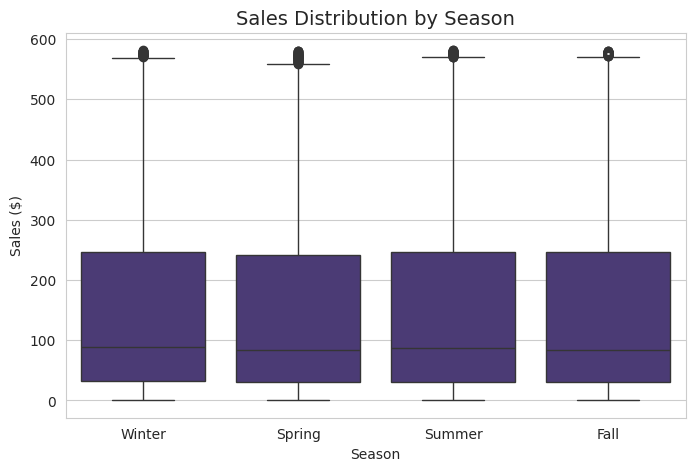

In [ ]:
# sales by season
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Season"], y=df["Sales"], order=season_order)
plt.title("Sales Distribution by Season", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Sales ($)")
plt.show()
# all the seasons are close in sales


In [ ]:
df['Country'].unique()

array(['Hungary', 'Australia', 'Algeria', 'Sweden', 'Canada',
       'United Kingdom', 'New Zealand', 'Iran', 'Guatemala', 'Tanzania',
       'Iraq', 'Philippines', 'Thailand', 'Malaysia', 'Brazil', 'Cuba',
       'Japan', 'Mexico', 'Sudan', 'United States', 'France', 'Taiwan',
       'Indonesia', 'Vietnam', 'China', 'Angola', 'Lebanon', 'Mozambique',
       'Singapore', 'Netherlands', 'Nigeria', 'South Africa', 'Egypt',
       'Venezuela', 'Austria', 'India', 'Spain', 'Turkey', 'Italy',
       'Germany', 'Nicaragua', 'Dominican Republic', 'Denmark',
       'El Salvador', 'Saudi Arabia', 'Zambia', 'Myanmar (Burma)',
       'Russia', 'Mongolia', 'Kenya', 'Belgium', 'Colombia', 'Estonia',
       'Madagascar', 'Morocco', 'Norway', 'Portugal', 'Sierra Leone',
       'Czech Republic', 'Central African Republic', 'Benin',
       'Bangladesh', 'Panama', 'Chile', 'South Korea', 'Moldova',
       'Switzerland', 'Uganda', 'Zimbabwe', 'Senegal', 'Hong Kong',
       'Niger', 'Democratic Republic o

In [ ]:
pd.set_option('display.max_columns', None)
df.sample(5)


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time,Promotion_Flag,Promotion_Above_Avg,Week,Day_of_Month,Holiday,Order Priority_Encoded,Ship Mode_Encoded,Segment_Encoded,Market_Encoded,Category_Encoded,Sub-Category_Encoded,Region_Encoded,Season_Encoded,Sales_Lag_1D,Sales_Lag_7D,Sales_Lag_30D,7days_sales_RA,Profit_30day_MA,Sales_EWMA,Profit_Lag_7,Profit_Lag_30,Shipping_Lag_30,Shipping_Lag_14
4143,2012-03-16,2012-03-19,Second Class,Maurice Satty,Consumer,Auburn,Alabama,United States,US,South,Office Supplies,Labels,"Dot Matrix Printer Tape Reel Labels, White, 50...",491.550000,5,0.00,9.240,26.375915,High,March,1,2012,4,0,False,Spring,2457.750,No Discount,2012-03,5.372646e+06,0,Friday,0.490000,3,2012-03,3,0,0,11,16,0,1,2,0,6,1,10,10,1,246.490581,246.490581,246.490581,170.439226,11.031483,179.029550,9.200,-8.4600,0.720000,1.79
41607,2013-07-22,2013-07-25,Second Class,Thea Hendricks,Consumer,Surabaya,Jawa Timur,Indonesia,APAC,Southeast Asia,Office Supplies,Paper,"Green Bar Memo Slips, Premium",17.967000,2,0.47,-4.113,1.900000,High,July,3,2013,0,0,False,Summer,35.934,High (20%+),2013-07,1.243821e+07,0,Monday,-0.228920,3,2013-07,3,1,1,30,22,0,1,2,0,0,1,12,11,2,27.930000,33.640000,14.432000,131.692512,1.384633,115.471359,-10.056,30.3000,7.040000,1.55
38464,2012-09-03,2012-09-07,Standard Class,Mark Packer,Home Office,Seoul,Seoul,South Korea,APAC,North Asia,Office Supplies,Binders,"Ibico 3-Hole Punch, Durable",31.950000,2,0.50,-16.650,2.610000,Medium,September,3,2012,0,0,False,Fall,63.900,High (20%+),2012-09,1.231697e+07,0,Monday,-0.521127,4,2012-09,4,1,1,36,3,0,3,3,2,0,1,3,8,0,48.672000,80.520000,32.400000,74.120654,5.159092,85.574972,4.200,-2.5280,2.710000,1.28
3748,2011-12-08,2011-12-12,Second Class,Patrick Bzostek,Home Office,Duisburg,North Rhine-Westphalia,Germany,EU,Central,Furniture,Bookcases,"Dania Classic Bookcase, Mobile",246.490581,2,0.10,66.084,26.375915,Medium,December,4,2011,3,0,False,Winter,1487.808,Small (0-10%),2011-12,5.083222e+06,0,Thursday,0.088834,4,2011-12,4,1,1,49,8,0,3,2,2,4,0,4,3,3,246.490581,319.968000,246.490581,144.645963,13.480723,146.323064,-25.374,11.1664,1.610000,11.02
7566,2014-07-09,2014-07-12,First Class,Sam Zeldin,Home Office,Pico Rivera,California,United States,US,West,Furniture,Furnishings,Deflect-o SuperTray Unbreakable Stackable Tray...,145.900000,5,0.00,62.737,44.850000,Critical,July,3,2014,2,0,False,Summer,729.500,No Discount,2014-07,7.378106e+06,0,Wednesday,0.430000,3,2014-07,3,0,0,28,9,0,0,0,2,6,0,9,12,2,408.006000,276.912000,246.490581,71.081083,7.109580,115.309809,9.240,73.7000,26.375915,6.56


In [ ]:
total_sales_per_country = df.groupby('Country')['Sales'].sum().reset_index()

def categorize_economic(total_sales):
    if total_sales < 3000:
        return 'Very Low'
    elif 3000 <= total_sales < 20000:
        return 'Low'
    elif 20000 <= total_sales < 60000:
        return 'Medium'
    else:
        return 'High'

total_sales_per_country['Economic_condition'] = total_sales_per_country['Sales'].apply(lambda x: categorize_economic(x))

df_with_economic = df.merge(total_sales_per_country[['Country', 'Economic_condition']], on='Country')

df = df_with_economic


In [ ]:
pd.set_option('display.max_columns', None)
df.sample(2)


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time,Promotion_Flag,Promotion_Above_Avg,Week,Day_of_Month,Holiday,Order Priority_Encoded,Ship Mode_Encoded,Segment_Encoded,Market_Encoded,Category_Encoded,Sub-Category_Encoded,Region_Encoded,Season_Encoded,Sales_Lag_1D,Sales_Lag_7D,Sales_Lag_30D,7days_sales_RA,Profit_30day_MA,Sales_EWMA,Profit_Lag_7,Profit_Lag_30,Shipping_Lag_30,Shipping_Lag_14,Economic_condition
21880,2013-03-25,2013-03-27,Second Class,Bruce Degenhardt,Consumer,Ramat Aviv,Tel Aviv,Israel,EMEA,EMEA,Office Supplies,Art,"Stanley Highlighters, Fluorescent",63.84,4,0.0,23.52,9.86,Critical,March,1,2013,0,0,False,Spring,255.36,No Discount,2013-03,1.116825e+07,0,Monday,0.368421,2,2013-03,2,0,0,13,25,0,0,2,0,3,1,2,5,1,117.96,42.72,152.22,104.984286,19.311990,103.329822,58.50,9.24,26.375915,15.93,Low
17315,2012-11-02,2012-11-04,First Class,Jim Epp,Corporate,Lagos,Lagos,Nigeria,Africa,Africa,Technology,Machines,"Okidata Printer, Wireless",80.55,1,0.0,9.24,19.04,Medium,November,4,2012,4,0,False,Fall,80.55,High (20%+),2012-11,9.913879e+06,0,Friday,-1.433520,2,2012-11,2,0,0,44,2,0,3,0,1,1,2,11,0,0,271.96,72.54,88.40,194.391429,9.202827,159.597546,0.45,32.88,4.080000,6.24,Medium


In [ ]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['Day_of_Week'] = df['Order Date'].dt.dayofweek
df['Is_Weekend'] = df['Day_of_Week'].isin([5, 6]).astype(int)
df['Total_sales'] = df['Sales'] * df['Quantity']


In [ ]:
df['Day_of_Month'] = df['Order Date'].dt.day


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = ["Order Priority", "Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Region"]

for col in categorical_columns:
    df[col + "_Encoded"] = encoder.fit_transform(df[col])

df[[*categorical_columns, *[col + "_Encoded" for col in categorical_columns]]].head()


,Order Priority,Ship Mode,Segment,Market,Category,Sub-Category,Region,Order Priority_Encoded,Ship Mode_Encoded,Segment_Encoded,Market_Encoded,Category_Encoded,Sub-Category_Encoded,Region_Encoded
0,High,Second Class,Consumer,EMEA,Office Supplies,Storage,EMEA,1,2,0,3,1,14,5
1,Medium,Standard Class,Consumer,APAC,Office Supplies,Supplies,Oceania,3,3,0,0,1,15,9
2,Medium,Standard Class,Consumer,Africa,Office Supplies,Storage,Africa,3,3,0,1,1,14,0
3,Medium,Standard Class,Consumer,APAC,Office Supplies,Paper,Oceania,3,3,0,0,1,12,9
4,High,Second Class,Home Office,EU,Office Supplies,Paper,North,1,2,2,4,1,12,7


In [ ]:
df.drop(columns=categorical_columns, inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 53 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order Date              51290 non-null  datetime64[ns]
 1   Ship Date               51290 non-null  datetime64[ns]
 2   Customer Name           51290 non-null  object        
 3   City                    51290 non-null  object        
 4   State                   51290 non-null  object        
 5   Country                 51290 non-null  object        
 6   Product Name            51290 non-null  object        
 7   Sales                   51290 non-null  float64       
 8   Quantity                51290 non-null  int64         
 9   Discount                51290 non-null  float64       
 10  Profit                  51290 non-null  float64       
 11  Shipping Cost           51290 non-null  float64       
 12  Month                   51290 non-null  int32 

In [ ]:
Q1 = df['Total_sales'].quantile(0.25)
Q3 = df['Total_sales'].quantile(0.75)
IQR2 = Q3 - Q1
lower_bound2 = Q1 - 1.5 * IQR2
upper_bound2 = Q3 + 1.5 * IQR2

df['Total_sales'] = df['Total_sales'].apply(
    lambda x: df['Total_sales'].mean() if x <= lower_bound2 or x >= upper_bound2 else x
)


In [ ]:
df.drop([
    'Customer Name', 'Product Name', 'Order Date',
    'Ship Date', 'City', 'State', 'Country', 'Sales',
    'Region_Encoded', 'Segment_Encoded'
], axis=1, inplace=True)


In [ ]:
fig = px.box(df, x='Shipping Cost', title='Boxplot of Shipping Cost')
fig.show()



In [ ]:
# handle shipping cost outliers
Q1 = df['Shipping Cost'].quantile(0.25)
Q3 = df['Shipping Cost'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Shipping Cost'] = df['Shipping Cost'].apply(
    lambda x: df['Shipping Cost'].mean() if x <= lower_bound or x >= upper_bound else x
)


In [ ]:
fig = px.box(df, x='Shipping Cost', title='Boxplot of Shipping Cost')
fig.show()

In [ ]:
df.columns

Index(['Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Month', 'Quarter',
       'Year', 'Day_of_Week', 'Is_Weekend', 'Is_Holiday', 'Season',
       'Total_sales', 'Discount Bin', 'YearMonth', 'Cumulative Sales', 'Hour',
       'DayOfWeek', 'Profit Margin', 'Processing Time (Days)', 'Year-Month',
       'Delivery Time', 'Promotion_Flag', 'Promotion_Above_Avg', 'Week',
       'Day_of_Month', 'Holiday', 'Order Priority_Encoded',
       'Ship Mode_Encoded', 'Market_Encoded', 'Category_Encoded',
       'Sub-Category_Encoded', 'Season_Encoded', 'Sales_Lag_1D',
       'Sales_Lag_7D', 'Sales_Lag_30D', '7days_sales_RA', 'Profit_30day_MA',
       'Sales_EWMA', 'Profit_Lag_7', 'Profit_Lag_30', 'Shipping_Lag_30',
       'Shipping_Lag_14', 'Economic_condition'],
      dtype='object')

In [ ]:

!pip install xgboost


In [ ]:

df.head()

,Quantity,Discount,Profit,Shipping Cost,Month,Quarter,Year,Day_of_Week,Is_Weekend,Is_Holiday,Season,Total_sales,Discount Bin,YearMonth,Cumulative Sales,Hour,DayOfWeek,Profit Margin,Processing Time (Days),Year-Month,Delivery Time,Promotion_Flag,Promotion_Above_Avg,Week,Day_of_Month,Holiday,Order Priority_Encoded,Ship Mode_Encoded,Market_Encoded,Category_Encoded,Sub-Category_Encoded,Season_Encoded,Sales_Lag_1D,Sales_Lag_7D,Sales_Lag_30D,7days_sales_RA,Profit_30day_MA,Sales_EWMA,Profit_Lag_7,Profit_Lag_30,Shipping_Lag_30,Shipping_Lag_14,Economic_condition
0,4,0.0,29.640,8.17,1,1,2011,5,1,False,Winter,264.480,No Discount,2011-01,1.142328e+07,0,Saturday,0.448276,4,2011-01,4,0,0,52,1,1,1,2,3,1,14,3,121.050,104.10000,50.520,NaN,NaN,66.120000,29.64,29.64,8.17,8.17,Low
1,3,0.1,36.036,9.72,1,1,2011,5,1,False,Winter,361.098,Small (0-10%),2011-01,1.118629e+07,0,Saturday,0.299387,7,2011-01,7,1,1,52,1,1,3,3,0,1,15,3,269.244,34.95000,56.124,NaN,NaN,73.352800,29.64,29.64,8.17,8.17,High
2,2,0.0,9.240,35.46,1,1,2011,5,1,False,Winter,816.600,No Discount,2011-01,8.130375e+06,0,Saturday,0.259956,5,2011-01,5,0,0,52,1,1,3,3,1,1,14,3,274.680,381.91464,439.344,NaN,NaN,118.012427,29.64,29.64,8.17,8.17,Medium
3,2,0.1,15.342,1.80,1,1,2011,5,1,False,Winter,110.484,Small (0-10%),2011-01,1.245094e+07,0,Saturday,0.277723,7,2011-01,7,1,1,52,1,1,3,3,0,1,12,3,14.970,26.82000,12.828,NaN,NaN,109.643036,29.64,29.64,8.17,8.17,High
4,3,0.5,-26.055,4.82,1,1,2011,5,1,False,Winter,134.595,High (20%+),2011-01,1.196121e+07,0,Saturday,-0.580742,4,2011-01,4,1,1,52,1,1,1,2,4,1,12,3,52.092,54.93600,56.460,NaN,NaN,101.005965,29.64,29.64,8.17,8.17,Medium


In [ ]:
df.shape

(51290, 43)

In [ ]:
df.drop(
    columns=[
        'Quarter', 'Is_Holiday', 'Season', 'Promotion_Flag', 'Promotion_Above_Avg',
        'Week', 'Holiday', 'Season_Encoded', 'Sales_Lag_1D', 'Sales_Lag_7D',
        'Sales_Lag_30D', '7days_sales_RA', 'Profit_30day_MA', 'Sales_EWMA',
        'Profit_Lag_7', 'Profit_Lag_30', 'Shipping_Lag_30', 'Shipping_Lag_14',
        'DayOfWeek', 'Economic_condition'
    ],
    inplace=True
)


In [ ]:
df.shape

(51290, 23)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Total_sales', axis=1)
y = df['Total_sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=30),
    "Gradient Boosting": GradientBoostingRegressor(random_state=30),
    "XGBoost": XGBRegressor(random_state=30, verbosity=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds_test = model.predict(X_test)
    preds_train = model.predict(X_train)

    # Calculate metrics
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    mae_test = mean_absolute_error(y_test, preds_test)
    mae_train = mean_absolute_error(y_train, preds_train)
    r2_test = r2_score(y_test, preds_test)
    r2_train = r2_score(y_train, preds_train)

    print(f"{name}:")
    print(f"  Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test:.4f}")
    print(f"  Train MAE:  {mae_train:.4f} | Test MAE:  {mae_test:.4f}")
    print(f"  Train R²:   {r2_train:.4f}   | Test R²:   {r2_test:.4f}")
    print("-" * 50)


Linear Regression:
  Train RMSE: 275.4160 | Test RMSE: 272.4717
  Train MAE:  181.0373 | Test MAE:  180.0206
  Train R²:   0.6073   | Test R²:   0.6124
--------------------------------------------------
Random Forest:
  Train RMSE: 67.9838 | Test RMSE: 180.5989
  Train MAE:  35.0522 | Test MAE:  94.0317
  Train R²:   0.9761   | Test R²:   0.8297
--------------------------------------------------
Gradient Boosting:
  Train RMSE: 195.8166 | Test RMSE: 199.3854
  Train MAE:  115.5401 | Test MAE:  116.8838
  Train R²:   0.8015   | Test R²:   0.7924
--------------------------------------------------
XGBoost:
  Train RMSE: 121.9783 | Test RMSE: 167.2162
  Train MAE:  65.3698 | Test MAE:  86.6126
  Train R²:   0.9230   | Test R²:   0.8540
--------------------------------------------------


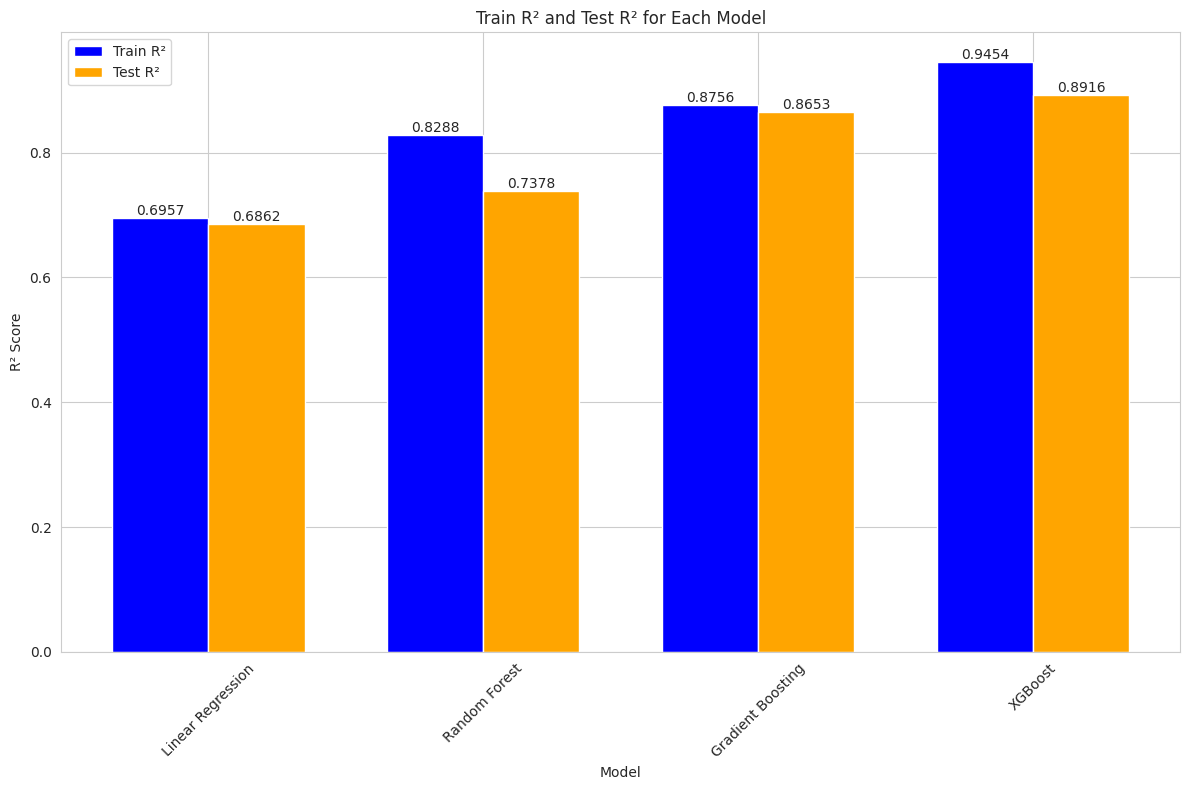

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

r2_scores = {
    'Model': ['Linear Regression',  'Random Forest',  'Gradient Boosting', 'XGBoost'],
    'Train R²': [0.6957, 0.8288,  0.8756, 0.9454],
    'Test R²': [0.6862, 0.7378, 0.8653, 0.8916]
}

r2_df = pd.DataFrame(r2_scores)

plt.figure(figsize=(12, 8))
bar_width = 0.35
index = range(len(r2_df['Model']))

train_bars = plt.bar(index, r2_df['Train R²'], bar_width, label='Train R²', color='blue')
test_bars = plt.bar([i + bar_width for i in index], r2_df['Test R²'], bar_width, label='Test R²', color='orange')

for bar in train_bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.4f}', ha='center', va='bottom')

for bar in test_bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.4f}', ha='center', va='bottom')

plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Train R² and Test R² for Each Model')
plt.xticks([i + bar_width / 2 for i in index], r2_df['Model'], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

xgbr = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

grid_search = GridSearchCV(
    estimator=xgbr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Tuned XGBoost RMSE: {rmse:.2f}")
print(f"Tuned XGBoost MAE: {mae:.2f}")
print(f"Tuned XGBoost R²: {r2:.4f}")

In [5]:
import xgboost as xgb
models = {

    "XGBoost": xgb.XGBRegressor(colsample_bytree= 1.0, gamma= 0, learning_rate= 0.05, max_depth= 7, n_estimators= 300, reg_alpha= 1, reg_lambda= 1.5, subsample= 0.8)

}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds_test = model.predict(X_test)
    preds_train = model.predict(X_train)

    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    mae_test = mean_absolute_error(y_test, preds_test)
    mae_train = mean_absolute_error(y_train, preds_train)
    r2_test = r2_score(y_test, preds_test)
    r2_train = r2_score(y_train, preds_train)

    print(f"{name}:")
    print(f"  Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test:.4f}")
    print(f"  Train MAE:  {mae_train:.4f} | Test MAE:  {mae_test:.4f}")
    print(f"  Train R²:   {r2_train:.4f}   | Test R²:   {r2_test:.4f}")
    print("-" * 50)

NameError: name 'X_train' is not defined

In [ ]:
import pickle
best_model = models["XGBoost"]

with open("xgboost_sales_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved as 'xgboost_sales_model.pkl'")

NaN in y before split: 0

Running XGBoost Tuning...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best parameters: {'colsample_bytree': np.float64(0.7139996989640846), 'gamma': np.float64(0.4868777594207296), 'learning_rate': np.float64(0.05655426808606085), 'max_depth': 8, 'n_estimators': 274, 'reg_alpha': np.float64(0.6183860093330873), 'reg_lambda': np.float64(1.2649239825343255), 'subsample': np.float64(0.9949692657420364)}

Tuned XGBoost Performance:
RMSE: 161.6207
MAE:  80.6461
R²:   0.8684


In [ ]:
%%writefile Customer_Sales_Prediction_Dashboard.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import pickle
import chardet

st.set_page_config(
    page_title="Customer Sales Prediction",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        color: #1f77b4;
        text-align: center;
        margin-bottom: 2rem;
        font-weight: bold;
    }
    .metric-card {
        background-color: #f8f9fa;
        padding: 1rem;
        border-radius: 10px;
        border-left: 4px solid #1f77b4;
        margin-bottom: 1rem;
    }
    .prediction-high {
        background: linear-gradient(135deg, #51cf66, #40c057);
        color: white;
        padding: 2rem;
        border-radius: 15px;
        text-align: center;
        animation: pulse 2s infinite;
    }
    .prediction-medium {
        background: linear-gradient(135deg, #ffd43b, #fcc419);
        color: white;
        padding: 2rem;
        border-radius: 15px;
        text-align: center;
    }
    .prediction-low {
        background: linear-gradient(135deg, #ff6b6b, #ee5a52);
        color: white;
        padding: 2rem;
        border-radius: 15px;
        text-align: center;
    }
    @keyframes pulse {
        0% { transform: scale(1); }
        50% { transform: scale(1.02); }
        100% { transform: scale(1); }
    }
</style>
""", unsafe_allow_html=True)

st.markdown('<div class="main-header">🏢 Customer Sales Prediction Dashboard</div>', unsafe_allow_html=True)

# Detect encoding
def detect_encoding(file_path):
    with open(file_path, 'rb') as file:
        raw_data = file.read()
        result = chardet.detect(raw_data)
        return result['encoding']

# Load data
@st.cache_data
def load_data():
    try:
        file_path = r"C:\Users\Media\Desktop\Original Data.csv"
        encodings_to_try = ['utf-8', 'latin-1', 'iso-8859-1', 'windows-1252', 'cp1252']
        df = None
        for enc in encodings_to_try:
            try:
                df = pd.read_csv(file_path, encoding=enc)
                st.success(f"✅ Successfully loaded with {enc} encoding")
                break
            except UnicodeDecodeError:
                continue
            except Exception as e:
                continue

        if df is None:
            df = pd.read_csv(file_path, encoding='latin-1', errors='replace')
            st.warning("⚠ Loaded with error replacement - some characters may be replaced")

        # Convert date columns
        date_columns = ['Order Date', 'Ship Date']
        for col in date_columns:
            if col in df.columns:
                try:
                    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
                except Exception as e:
                    st.warning(f"⚠ Could not convert {col}: {e}")

        from pandas.tseries.holiday import USFederalHolidayCalendar

        # Create features
        if 'Order Date' in df.columns:
            df['Month'] = df['Order Date'].dt.month
            df['Quarter'] = df['Order Date'].dt.quarter
            df['Year'] = df['Order Date'].dt.year
            df['Day_of_Week'] = df['Order Date'].dt.dayofweek
            df['Is_Weekend'] = df['Day_of_Week'].isin([5,6]).astype(int)

        # Holiday feature
        try:
            if 'Order Date' in df.columns:
                cal = USFederalHolidayCalendar()
                holidays = cal.holidays(start=df['Order Date'].min(), end=df['Order Date'].max())
                df['Is_Holiday'] = df['Order Date'].isin(holidays).astype(int)
        except Exception as e:
            st.warning(f"⚠ Could not create holiday features: {e}")

        # Season
        if 'Month' in df.columns:
            df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12,1,2] else
                                            'Spring' if x in [3,4,5] else
                                            'Summer' if x in [6,7,8] else
                                            'Fall')

        # Total sales
        if all(col in df.columns for col in ['Sales','Quantity']):
            df['Total_sales'] = df['Sales'] * df['Quantity']
        else:
            st.error("❌ Missing 'Sales' or 'Quantity' columns")

        # Drop unnecessary columns
        columns_to_drop = ['Row ID','Order ID','Customer ID','Postal Code','Product ID']
        df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True, errors='ignore')

        # Numeric columns
        numeric_columns = ["Sales", "Discount", "Profit", "Shipping Cost"]
        for col in numeric_columns:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                df[col].fillna(df[col].mean(), inplace=True)

        # Promotion
        if 'Discount' in df.columns:
            df['Promotion_Flag'] = (df['Discount']>0).astype(int)
            avg_discount = df['Discount'].mean()
            df['Promotion_Above_Avg'] = (df['Discount']>avg_discount).astype(int)

        # Additional date features
        if 'Order Date' in df.columns:
            df['Day_of_Month'] = df['Order Date'].dt.day

        # Label encoding
        categorical_columns = ["Order Priority","Ship Mode","Segment","Market","Category","Sub-Category","Region","Season"]
        encoder = LabelEncoder()
        for col in categorical_columns:
            if col in df.columns:
                try:
                    df[col+"_Encoded"] = encoder.fit_transform(df[col].astype(str))
                except:
                    continue
        # Drop original categorical
        original_cat_cols = ["Order Priority","Ship Mode","Segment","Market","Category","Sub-Category","Region"]
        df.drop(columns=[col for col in original_cat_cols if col in df.columns], inplace=True, errors='ignore')

        # Drop final unnecessary columns
        final_drop = ['Customer Name','Product Name','Order Date','Ship Date','City','State','Country','Sales','Region_Encoded','Segment_Encoded']
        df.drop(columns=[col for col in final_drop if col in df.columns], inplace=True, errors='ignore')

        # Handle missing
        for col in df.columns:
            if df[col].isnull().any():
                if df[col].dtype in ['float64','int64']:
                    df[col].fillna(df[col].mean(), inplace=True)
                else:
                    df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown', inplace=True)

        # Prepare X,y
        if 'Total_sales' in df.columns:
            X = df.drop('Total_sales', axis=1)
            y = df['Total_sales']
            for col in X.columns:
                if X[col].dtype=='object':
                    try:
                        X[col] = pd.to_numeric(X[col], errors='coerce')
                        X[col].fillna(X[col].mean(), inplace=True)
                    except:
                        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
            return df, X, y
        else:
            st.error("❌ 'Total_sales' column not found")
            return None, None, None

    except Exception as e:
        st.error(f"❌ Error loading data: {e}")
        return None, None, None

# Load model
@st.cache_resource
def load_model():
    try:
        model_path = r"C:\Users\Media\Desktop\xgboost_sales_model (1).pkl"
        with open(model_path,'rb') as file:
            model = pickle.load(file)
        return model
    except Exception as e:
        st.error(f"❌ Error loading model: {e}")
        st.error("Please make sure the model file exists at the specified path")
        return None

# Load data & model
df, X, y = load_data()
best_model = load_model()

if df is None:
    st.error("Failed to load data. Check data file path.")
    st.stop()

correct_feature_order = list(best_model.feature_names_in_) if best_model is not None and hasattr(best_model,'feature_names_in_') else list(X.columns)

# Sidebar navigation
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", ["Data Overview","Model Info","Sales Prediction"])

# --- Pages ---
if page=="Data Overview":
    st.header("📊 Data Overview")
    col1,col2 = st.columns(2)
    with col1:
        st.subheader("Dataset Preview")
        st.dataframe(df.head(10))
        st.subheader("Dataset Shape")
        st.write(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    with col2:
        st.subheader("Data Statistics")
        st.dataframe(df.describe())
        st.subheader("Features used for prediction")
        for col in X.columns:
            st.write(f"- {col}")

    st.subheader("Sales Distribution Analysis")
    col1,col2 = st.columns(2)
    with col1:
        fig,ax = plt.subplots(figsize=(10,6))
        ax.hist(df['Total_sales'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        ax.set_xlabel('Total Sales')
        ax.set_ylabel('Frequency')
        ax.set_title('Distribution of Total Sales')
        st.pyplot(fig)
    with col2:
        monthly_sales = df.groupby('Month')['Total_sales'].mean()
        fig,ax = plt.subplots(figsize=(10,6))
        monthly_sales.plot(kind='bar', ax=ax, color='lightcoral')
        ax.set_xlabel('Month')
        ax.set_ylabel('Average Sales')
        ax.set_title('Average Sales by Month')
        plt.xticks(rotation=45)
        st.pyplot(fig)

elif page=="Model Info":
    st.header("🤖 Model Information")
    if best_model is not None:
        st.success("✅ XGBoost Model Loaded Successfully!")
        st.subheader("Model Details")
        st.write(f"*Model Type:* {type(best_model).__name__}")
        st.subheader("Feature Order Required by Model")
        st.write(correct_feature_order)
        if hasattr(best_model,'feature_importances_'):
            st.subheader("Feature Importance")
            feat_imp = pd.DataFrame({'feature':correct_feature_order,'importance':best_model.feature_importances_}).sort_values('importance',ascending=True)
            fig,ax=plt.subplots(figsize=(10,8))
            ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
            ax.set_xlabel('Importance')
            ax.set_title('Feature Importance for Sales Prediction')
            ax.grid(axis='x', alpha=0.3)
            st.pyplot(fig)
            st.subheader("Top 5 Features")
            top5 = feat_imp.tail(5)
            for idx,row in top5.iterrows():
                st.write(f"{row['feature']}: {row['importance']:.4f}")
        else:
            st.info("Feature importance not available")
    else:
        st.error("❌ Model failed to load")

elif page=="Sales Prediction":
    st.header("🔮 Sales Prediction")
    if best_model is None:
        st.error("Load the model first")
        st.stop()
    st.markdown("### Enter Customer/Order Details")
    with st.form("prediction_form"):
        col1,col2 = st.columns(2)
        with col1:
            Quantity = st.slider("Quantity",1,20,3)
            Discount = st.slider("Discount Rate",0.0,1.0,0.1,0.01)
            Profit = st.number_input("Expected Profit",-1000.0,10000.0,50.0,10.0)
            Shipping_Cost = st.number_input("Shipping Cost",0.0,1000.0,25.0,5.0)
        with col2:
            Month = st.selectbox("Month",options=list(range(1,13)),index=5)
            Year = st.selectbox("Year", options=[2011,2012,2013,2014,2015], index=3)
            Day_of_Week = st.selectbox("Day of Week", options=list(range(7)), index=2)
            Is_Weekend = st.selectbox("Is Weekend", options=[0,1], index=0)
            Day_of_Month = st.slider("Day of Month",1,31,15)
        col3,col4 = st.columns(2)
        with col3:
            Ship_Mode_Encoded = st.selectbox("Ship Mode", options=[0,1,2,3], index=1)
            Market_Encoded = st.selectbox("Market", options=[0,1,2,3,4], index=3)
        with col4:
            Category_Encoded = st.selectbox("Category", options=[0,1,2], index=1)
            Sub_Category_Encoded = st.slider("Sub-Category Code",0,16,8)
            Order_Priority_Encoded = st.selectbox("Order Priority", options=[0,1,2,3], index=2)
        submitted = st.form_submit_button("Predict Sales", use_container_width=True)
        if submitted:
            input_dict = {
                'Quantity': Quantity, 'Discount': Discount, 'Profit': Profit, 'Shipping Cost': Shipping_Cost,
                'Month': Month, 'Year': Year, 'Day_of_Week': Day_of_Week, 'Is_Weekend': Is_Weekend,
                'Day_of_Month': Day_of_Month, 'Ship Mode_Encoded': Ship_Mode_Encoded,
                'Market_Encoded': Market_Encoded, 'Category_Encoded': Category_Encoded,
                'Sub-Category_Encoded': Sub_Category_Encoded, 'Order Priority_Encoded': Order_Priority_Encoded
            }
            input_data_ordered=[]
            for feat in correct_feature_order:
                if feat in input_dict:
                    input_data_ordered.append(input_dict[feat])
                else:
                    default_value = X[feat].mean() if feat in X.columns else 0
                    input_data_ordered.append(default_value)
                    st.warning(f"⚠ Using default value for missing feature: {feat}")
            input_df = pd.DataFrame([input_data_ordered], columns=correct_feature_order)
            try:
                prediction = best_model.predict(input_df)[0]
                st.markdown("### 📊 Prediction Result")
                sales_75 = df['Total_sales'].quantile(0.75)
                sales_25 = df['Total_sales'].quantile(0.25)
                if prediction>sales_75:
                    cls="prediction-high"; cat="High Sales"; emoji="💰"
                elif prediction>sales_25:
                    cls="prediction-medium"; cat="Medium Sales"; emoji="📈"
                else:
                    cls="prediction-low"; cat="Low Sales"; emoji="📉"
                c1,c2,c3 = st.columns([1,2,1])
                with c2:
                    st.markdown(f'<div class="{cls}"><h2>{emoji} {cat}</h2><h1>${prediction:,.2f}</h1><p>Predicted Total Sales Amount</p></div>', unsafe_allow_html=True)
            except Exception as e:
                st.error(f"Error making prediction: {e}")
                st.error("Check required features and order")

st.markdown("---")
st.markdown("### 💡 About This Dashboard")
st.markdown("""
This dashboard provides sales prediction capabilities using a pre-trained XGBoost model.
- *Data Overview*: Explore the dataset and understand feature distributions
- *Model Info*: Learn about the trained model and feature importance
- *Sales Prediction*: Predict total sales based on customer and order features

*Note*: The model uses historical sales data to forecast future sales performance.
""")


Writing Customer_Sales_Prediction_Dashboard.py
